<a href="https://colab.research.google.com/github/rebeccalordan-perret/plots-model-comparison/blob/main/cross_comparison_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Initialization

In [38]:
import subprocess
import sys
import logging
import os
import pandas as pd
from pathlib import Path
from typing import Literal

# get rid of the non-installed font warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)


# If it is run for the first time, we need install the repo and restart the notebook
repo_path = "/content/plots-model-comparison"

if os.path.exists(repo_path):
    # pull updates
    result = subprocess.run(
        ["git", "-C", repo_path, "pull"],
        capture_output=True,
        text=True
    )
else:
    # clone repo if missing
    result = subprocess.run(
        ["git", "clone",
         "https://github.com/rebeccalordan-perret/plots-model-comparison",
         repo_path],
        capture_output=True,
        text=True
    )
print(result)
# Check if successful (exit code 0 means success)
if result.returncode == 0:
    sys.path.insert(0,'/content/plots-model-comparison')
    from cross_tools.plots import Plots
else:
    # add the package to the path
    print("⚠️ Please restart the runtime to use the cloned repository.")
    print("   Go to: Runtime → Restart Session")

#  List of files with:
# name: name to be displayed in the plots
# id:  model_id in CROSSHub
# summer: name of the summer day reported by the model
# summerDay: data of the summer typical day in the format dd.mm.yyyy
# winter: name of the winter day reported by the model
# winterDay: data of the winter typical day in the format dd.mm.yyyy
# color: color used for the scatter plots in hex

# color: color to be used for the model in scatter plots
model_list =  [
          #{'name': 'Calliope', 'file': 'resultsCross_Calliope','summer':'Jul 20','winter':'Feb 08','color':'#D57CBE'},
          #{'name': 'Expanse', 'file': 'resultsCross_Expanse','summer':'Jul 02','winter':'Jan 01','color':'#FF7D0D'},
          {'name': 'Nexus-e', 'id':'nexuse','summer':'Typical day','summerDay':'02.07.2050','winter':'Typical day','winterDay':'08.02.2050','color':'#0072B2'},
          #{'name': 'SecMod', 'id': 'secmod','summer':'Typical day','summerDay':'01.07.2050','winter':'Typical day','winterDay':'01.02.2050','color':'#9565BD'},
          {'name': 'SES', 'id':'ses','summer':'Typical day','summerDay':'01.08.2050','winter':'Typical day','winterDay':'01.02.2050','color':'#E69F00'},
          {'name': 'SES-ETH', 'id': 'seseth','summer':'Typical day','summerDay':'01.07.2050','winter':'Typical day','winterDay':'01.02.2050','color':'#009E73'},
          {'name': 'STEM', 'id': 'stem','summer':'Week day','summerDay':'01.07.2050','winter':'Week day','winterDay':'01.02.2050','color':'#CC79A7'},
          # {'name': 'ZEN-Garden','id':'zengarden', 'summer':'Week day','summerDay':'01.07.2050','winter':'Week day','winterDay':'01.02.2050','color':'#00BFC4'},
         #{'name': 'Empa', 'file': 'resultsCross_VSE','summer':'Jul 11','winter':'Feb 15','color':'#8B5349'},
          #{'name': 'EP2050+\nZero Basis', 'file': 'resultsCross_EP','summer':'avg. Aug. 13-19','winter':'avg. Feb. 7-13','color':'#7F7F7F'}
          ]

# Create the object that produces the plots and processes the data
# Name of the csv file with the results
fileResults = "/content/plots-model-comparison/results/nuclear_2026_03_17"


CompletedProcess(args=['git', '-C', '/content/plots-model-comparison', 'pull'], returncode=0, stdout='Updating 0fcb88e..72959b1\nFast-forward\n cross_comparison_colab.ipynb | 46 ++++++++++++++++++++++++++++++--------------\n 1 file changed, 32 insertions(+), 14 deletions(-)\n', stderr='From https://github.com/rebeccalordan-perret/plots-model-comparison\n   0fcb88e..72959b1  main       -> origin/main\n')


#### Remove Nexus-e transit flows

In [39]:

def remove_nexus_e_transit_flows():
  # Modify the dataset to take into account the transit flows in Nexus-e results
  results_dataset = pd.read_csv(fileResults + ".csv")
  results_dataset.set_index(
      list(results_dataset.columns.drop(["value", "uploaded_by", "uploaded_at"])),
      inplace=True
  )

  # Re-create nexus-e annual values from the monthly ones with removing the
  # transit flows
  nexus_e = pd.read_excel(
      Path(repo_path) / "results" / "nexus_e_transit_flows.xlsx",
      sheet_name="monthly"
  )

  # Drop rows about transit flows
  nexus_e = nexus_e[
      ~nexus_e.use_technology_fuel.isin(
          ["imports_transit", "exports_transit"]
      )
  ]

  # Add missing column
  nexus_e.insert(
      loc=len(nexus_e.columns)-12,
      column="timestamp",
      value=2050
  )

  # Sum all value columns into a new "value" column
  value_columns = [
      "01.2050",
      "02.2050",
      "03.2050",
      "04.2050",
      "05.2050",
      "06.2050",
      "07.2050",
      "08.2050",
      "09.2050",
      "10.2050",
      "11.2050",
      "12.2050",
  ]
  nexus_e.insert(
      loc=len(nexus_e.columns)-12,
      column="value",
      value=0
  )
  for value_column in value_columns:
      nexus_e.value = (
          nexus_e.value
          + nexus_e[value_column]
      )
  nexus_e = nexus_e[nexus_e.columns.drop(value_columns)]

  # Rename elements with respect to summed values
  nexus_e.time_resolution = "annual"
  nexus_e.loc[
      nexus_e.variable == "electricity_supply_monthly",
      "variable"
  ] = "electricity_supply"
  nexus_e.loc[
      nexus_e.variable == "electricity_consumption_monthly",
      "variable"
  ] = "electricity_consumption"

  # Set index such that it correctly updates results_dataset
  nexus_e.set_index(
      results_dataset.index.names,
      inplace=True
  )

  # Update and save results
  results_dataset.update(nexus_e)
  new_file_path = (
      Path(repo_path)
      / "results"
      / (fileResults + "_without_nexus_e_transit_flows.csv")
  )
  results_dataset.to_csv(new_file_path)
  print(f"New file created: {new_file_path}")


create_new_results_file_without_nexus_e_transit_flows = True
if (
    "_without_nexus_e_transit_flows" not in fileResults
    and create_new_results_file_without_nexus_e_transit_flows
):
  remove_nexus_e_transit_flows()
  fileResults += "_without_nexus_e_transit_flows"
  print(f"fileResults has been changed to: {fileResults}\n")

New file created: /content/plots-model-comparison/results/nuclear_2026_03_17_without_nexus_e_transit_flows.csv
fileResults has been changed to: /content/plots-model-comparison/results/nuclear_2026_03_17_without_nexus_e_transit_flows



#### Add seasonal trade

In [40]:
# Seasonal Trade
# Reformat to better merge with other results file

def add_seasonal_trade():
  # Load data
  seasonal_trade_file = (
    Path()
    / "plots-model-comparison"
    / "results"
    / "nuclear_results_seasonaltrade_20260317.xlsx"
  )
  seasonal_trade = pd.read_excel(seasonal_trade_file)

  # Reformat WACC column
  #
  # Example:
  #   5 -> "wacc_5"
  #
  seasonal_trade = seasonal_trade.astype({"WACC": str})
  seasonal_trade.loc[
      seasonal_trade.WACC == "5",
      "WACC"
  ] = "wacc_5"
  seasonal_trade.loc[
      seasonal_trade.WACC == "8",
      "WACC"
  ] = "wacc_8"


  # Rearrange value columns
  #
  # Example:
  #   | season | Electricity Imports (TWh) |
  #   --------------------------------------
  #   | summer |          1,23             |
  #
  # Becomes:
  #   | variable                | use_technology_fuel | value |
  #   ---------------------------------------------------------
  #   | electricity_consumption | summer_imports      |  1,23 |
  #
  value_columns = [
      "Electricity Imports (TWh)",
      "Electricity Exports (TWh)",
  ]
  seasonal_trade = seasonal_trade.melt(
      id_vars=tuple(seasonal_trade.columns.drop(value_columns)),
      value_vars=value_columns,
      var_name="use_technology_fuel"
  )
  # Force positive values
  # Original export values of the SES-ETH model are negative
  seasonal_trade.value = abs(seasonal_trade.value)
  for season in ["summer", "winter"]:
    for direction in ["imports", "exports"]:
      seasonal_trade.loc[
          (
              (seasonal_trade.use_technology_fuel == f"Electricity {direction.capitalize()} (TWh)")
              & (seasonal_trade.season == season)
          ),
          "use_technology_fuel"
      ] = f"{season}_{direction}"
  seasonal_trade = seasonal_trade[seasonal_trade.columns.drop("season")]
  seasonal_trade.insert(
      loc=0,
      column="variable",
      value=""

  )
  def map_direction_to_variable(direction: str) -> str:
    if "imports" in direction:
      return "electricity_supply"
    elif "exports" in direction:
      return "electricity_consumption"
    else:
      return direction
  seasonal_trade.variable = seasonal_trade.use_technology_fuel.apply(map_direction_to_variable)

  # Scale values for SES mdodel
  # It looks like the values of this model were given in GWh instead of TWh
  seasonal_trade.loc[
      seasonal_trade.Model == "SES",
      "value"
  ] = seasonal_trade.loc[
      seasonal_trade.Model == "SES",
      "value"
  ].apply(lambda x: x / 1000)
  print(seasonal_trade[seasonal_trade.Model == "SES"])

  # Rename models
  def rename_model(model: str) -> str:
    new_name = {
        "STEM": "stem",
        "SES-ETH": "seseth",
        "SES": "ses",
        "Nexus-e": "nexuse"
    }
    return new_name[model] if model in new_name else model
  seasonal_trade.Model = seasonal_trade.Model.apply(rename_model)

  # Rename columns
  seasonal_trade.rename(
      columns={
          "WACC": "scenario_variant",
          "Scenario": "scenario_name",
          "Model": "model",
      },
      inplace=True
  )

  # Add missing columns
  for missing_column, initial_value in {
      "scenario_group": "nuclear2025",
      "country": "CH",
      "unit": "TWh",
      "time_resolution": "annual",
      "timestamp": "2050"
  }.items():
    seasonal_trade.insert(
        loc=0,
        column=missing_column,
        value=initial_value
    )

  # Rearrange columns
  seasonal_trade = seasonal_trade[
      [
          "scenario_group",
          "scenario_name",
          "scenario_variant",
          "variable",
          "use_technology_fuel",
          "country",
          "model",
          "unit",
          "time_resolution",
          "timestamp",
          "value",
      ]
  ]

  # Inject seasonal data into results
  results = pd.read_csv(fileResults + ".csv")
  results.set_index(
      list(results.columns.drop(["uploaded_by", "uploaded_at", "value", "use_technology_fuel"])),
      inplace=True
  )
  seasonal_trade.set_index(
      results.index.names,
      inplace=True
  )
  results = pd.concat([results, seasonal_trade])

  new_file_path = (
      Path(repo_path)
      / "results"
      / (fileResults + "_with_seasonal_trade.csv")
  )
  results.to_csv(new_file_path)
  print(f"New file created: {new_file_path}")

create_new_results_file_with_seasonal_trade = True
if (
    "_with_seasonal_trade" not in fileResults
    and create_new_results_file_with_seasonal_trade
):
  add_seasonal_trade()
  fileResults += "_with_seasonal_trade"
  print(f"fileResults has been changed to: {fileResults}\n")

                    variable    WACC                Scenario Model  \
48        electricity_supply  wacc_5       abroad-resnuc-low   SES   
49        electricity_supply  wacc_5    abroad-resnuc-medium   SES   
50        electricity_supply  wacc_5      abroad-resnuc-high   SES   
51        electricity_supply  wacc_5  abroad-resnuc-phaseout   SES   
52        electricity_supply  wacc_5          abroad-res-low   SES   
..                       ...     ...                     ...   ...   
355  electricity_consumption  wacc_8     abroad-res-phaseout   SES   
356  electricity_consumption  wacc_8        abroad-nores-low   SES   
357  electricity_consumption  wacc_8     abroad-nores-medium   SES   
358  electricity_consumption  wacc_8       abroad-nores-high   SES   
359  electricity_consumption  wacc_8   abroad-nores-phaseout   SES   

    use_technology_fuel     value  
48       summer_imports  4.566165  
49       summer_imports  5.541898  
50       summer_imports  5.523252  
51       summer

#### Initialize main object

In [41]:

# Scenario names and corresponding colors
sce = ['abroad-resnuc-high','abroad-resnuc-medium','abroad-resnuc-low','abroad-resnuc-phaseout','abroad-res-high','abroad-res-medium','abroad-res-low','abroad-res-phaseout','abroad-nores-high','abroad-nores-medium','abroad-nores-low','abroad-nores-phaseout']
sceColors = ['#9FBA3D','#E9442E','#EC9235','#3F89BD','#8E44AD','#1ABC9C','#F1C40F','#34495E','#9FBA3D','#E9442E','#EC9235','#3F89BD','#8E44AD','#1ABC9C','#F1C40F','#34495E']
# Folders where the plots will be created
folder_plots='plots'


cross_plots = Plots(fileResults,model_list,sce,sceColors,folder_plots)
listModels = cross_plots.modelsid
print(cross_plots.modelsid)
print(cross_plots.model_colors)
print(hasattr(cross_plots, "model_colors"))

/content/plots-model-comparison/cross_tools/plots.py:218: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  mask_hourly = data['time_resolution'].isin(['typical-day', 'hourly'])


=== Plots object initialized ===

Attributes:
  models: dict
  modelsid: list
  model_colors: list
  typicalDays: dict
  folder_plots: str
  allData: DataFrame
  yearsModel: dict
  sce: list
  sceColors: list
  sceModel: dict
  sceVariants: list
  annualData: DataFrame

Methods:
  plotBarHorizontal()
  plotBarHorizontalSigned()
  plotBarVertical()
  plotBarVerticalSigned()
  plotBarVerticalSignedFuels()
  plotHourlySignedProfile()
  plotLineByScenario()
  plotScatter()
  plotTechDist()


['nexuse', 'ses', 'seseth', 'stem']
['#0072B2', '#E69F00', '#009E73', '#CC79A7']
True


### Annual electricity supply with net imports

In [42]:
#cross_plots.allData
df = cross_plots.allData.loc['abroad-res-phaseout','wacc_5',:, ['electricity_supply', 'electricity_consumption'], ['imports', 'exports','wind'], 'annual', 2050, :]
df = df.reset_index() # Reset index to make 'model' a column
df = df[['model', 'use_technology_fuel', 'value']]
df = df.pivot(index='model', columns='use_technology_fuel', values='value')
df['netimports']=df['imports']-df['exports']
df

use_technology_fuel,exports,imports,wind,netimports
model,,,,
nexuse,21.839625,13.618074,4.181437,-8.221551
ses,10.766421,16.133084,8.606508,5.366663
seseth,6.077116,20.629642,1.622664,14.552526
stem,1.341674,7.838646,0.280636,6.496972


In [ ]:
df = cross_plots.allData.loc['abroad-res-phaseout','wacc_5',:, ['electricity_supply','electricity_consumption'],
 ['hydro_dam','hydro_ror','nuclear','spv', 'geothermal_pp','methane_pp','hydrogen_pp','liquids_pp','waste_pp','wind','net_storage_out', 'imports','exports'], 'annual', 2050, :]
df = df.reset_index() # Reset index to make 'model' a column
df = df[['model', 'use_technology_fuel', 'value']]
df = df.pivot(index='model', columns='use_technology_fuel', values='value')
df['thermal_tot']=df['hydrogen_pp']+df['methane_pp']+df['liquids_pp']+df['waste_pp']
df['net-imports'] = df['imports']-df['exports']
df['hydro_tot']= df['hydro_ror']+ df['hydro_dam']
columns_to_sum = ['hydro_tot','nuclear','spv', 'geothermal_pp','methane_pp','hydrogen_pp','liquids_pp','waste_pp','wind','net_storage_out','net-imports']
df['wind_share']= df['wind']/df[columns_to_sum].sum(axis=1)
df['solar_share']= df['spv']/df[columns_to_sum].sum(axis=1)
df['netstorageout_share']= df['net_storage_out']/df[columns_to_sum].sum(axis=1)
df['hydro_share']= df['hydro_tot']/df[columns_to_sum].sum(axis=1)
df['netimports_share']= df['net-imports']/df[columns_to_sum].sum(axis=1)
df['thermal_share']= df['thermal_tot']/df[columns_to_sum].sum(axis=1)
df



use_technology_fuel,exports,geothermal_pp,hydro_dam,hydro_ror,hydrogen_pp,imports,liquids_pp,methane_pp,net_storage_out,nuclear,...,wind,thermal_tot,net-imports,hydro_tot,wind_share,solar_share,netstorageout_share,hydro_share,netimports_share,thermal_share
model,,,,,,,,,,,,,,,,,,,,,
nexuse,49.213845,NaN,17.766088,19.186795,NaN,40.992294,NaN,0.589579,3.332231,0.000000e+00,...,4.181437,NaN,-8.221551,36.952883,0.055205,0.501724,0.043994,0.487870,-0.108545,NaN
ses,10.766421,0.000063,20.019784,16.308638,1.176989,16.133084,0.122840,0.011576,0.000000,6.092209e-07,...,8.606508,1.311405,5.366663,36.328422,0.098069,0.411883,0.000000,0.413953,0.061152,0.014943
seseth,6.077116,0.000000,19.496902,12.713213,0.000000,20.629642,0.000000,0.000000,0.000000,4.432500e-03,...,1.622664,2.606199,14.552526,32.210115,0.017194,0.459636,0.000000,0.341305,0.154202,0.027616
stem,1.341674,0.002981,20.787781,16.800324,0.000000,7.838646,0.000023,1.100520,0.000000,0.000000e+00,...,0.280636,4.159130,6.496972,37.588105,0.003241,0.439500,0.000000,0.434146,0.075041,0.048038


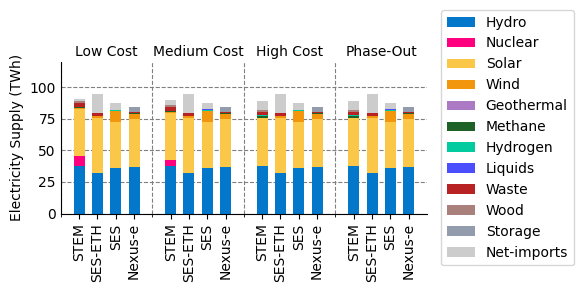

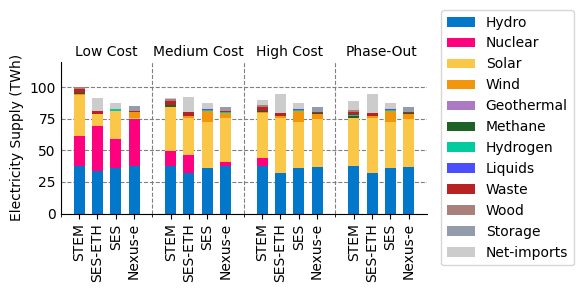

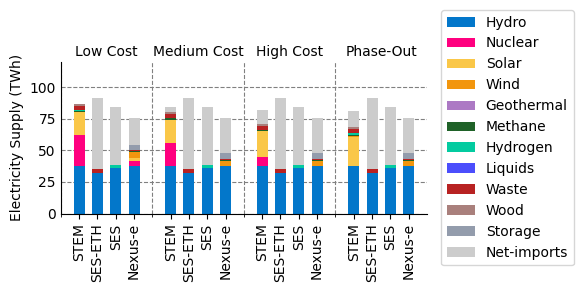

In [43]:
# name: name of the technology or group of technologies (valid names: https://sweet-cross.github.io/instructions-data/docs/sets/tech_generation/)
# data: list with the technologies that correspond to this category
# color: color to use for this category
varList_supply_net = [
    {'name':'Hydro','data':['hydro_dam','hydro_ror'],'color':'#0377CA'},
    {'name':'Nuclear','data':['nuclear'],'color':'#FF007F'},
    {'name':'Solar','data':['spv'],'color':'#FAC748'},
    {'name':'Wind','data':['wind'],'color':'#F2960E'},
    {'name':'Geothermal','data':['geothermal_pp'],'color':'#ac79c4'},
    {'name':'Methane','data':["methane_pp",'fuel_cell_methane'],'color':'#1f6228'},
    {'name':'Hydrogen','data':['hydrogen_pp','fuel_cell_h2'],'color':'#03CBA0'},
    {'name':'Liquids','data':['liquids_pp'],'color':'#4B4EFC'},
    {'name':'Waste','data':['waste_pp'],'color':'#b82222'},
    {'name':'Wood','data':['wood_pp'],'color':'#a9807c'},
    {'name':'Storage','data':['net_storage_out'],'color':'#939CAC'},
    {'name':'Net-imports','data':['net_imports'],'color':'#CCCCCC'}
    #     {'name':'Storage','data':['battery_out','phs_out'],'color':'#939CAC'},
    #     {'name':'Imports','data':['imports'],'color':'#CCCCCC'}
   ]

varName = 'electricity_supply'
xlabel = 'Electricity Supply (TWh)'
xmax = 120
fileName = 'elecSupply_tech_net'
year = 2050

scenario_list={
    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-low','wacc_5'):'Low Cost',
        ('abroad-res-medium','wacc_5'):'Medium Cost',
        ('abroad-res-high','wacc_5'):'High Cost',
        ('abroad-res-phaseout','wacc_5'):'Phase-Out',

    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-low','wacc_5'):'Low Cost',
        ('abroad-resnuc-medium','wacc_5'):'Medium Cost',
        ('abroad-resnuc-high','wacc_5'):'High Cost',
        ('abroad-resnuc-phaseout','wacc_5'):'Phase-Out',

    },
    'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-low','wacc_5'):'Low Cost',
        ('abroad-nores-medium','wacc_5'):'Medium Cost',
        ('abroad-nores-high','wacc_5'):'High Cost',
        ('abroad-nores-phaseout','wacc_5'):'Phase-Out',

    },
    }

for name, scenarios in scenario_list.items():
    #cross_plots.plotBarHorizontal(
    cross_plots.plotBarVertical(
        listModelsid=listModels,
        listSce=scenarios,
        varName = varName,
        varList=varList_supply_net,
        year=year,
        scale=1,
        label=xlabel,
        figmax = xmax,
        fileName = fileName+'_'+name+'wacc5',
        invert=False, legend=True, pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
    #    width=5, height=12,
        width=12, height=5,
        group_by="scenario", # 'scenario' or 'model'
        multi=False,          # <--- one plot
    )

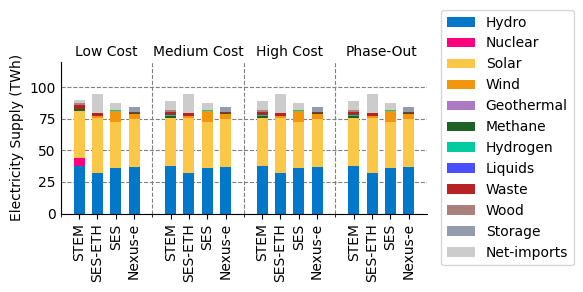

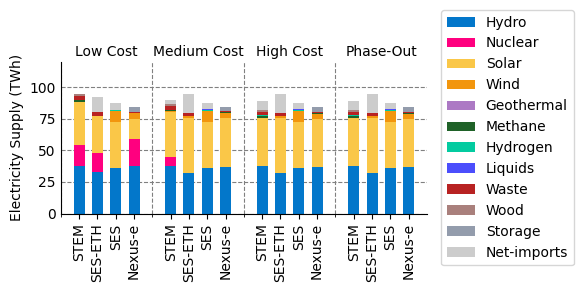

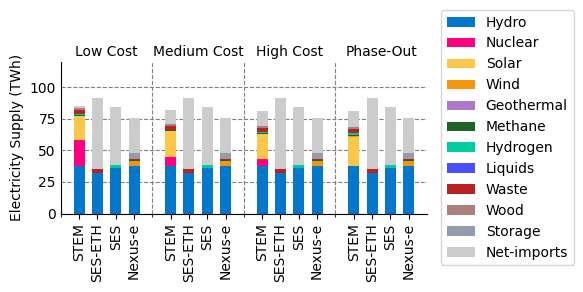

In [44]:
# Annual electricity supply with net imports

# name: name of the technology or group of technologies (valid names: https://sweet-cross.github.io/instructions-data/docs/sets/tech_generation/)
# data: list with the technologies that correspond to this category
# color: color to use for this category
varList_supply_net = [
    {'name':'Hydro','data':['hydro_dam','hydro_ror'],'color':'#0377CA'},
    {'name':'Nuclear','data':['nuclear'],'color':'#FF007F'},
    {'name':'Solar','data':['spv'],'color':'#FAC748'},
    {'name':'Wind','data':['wind'],'color':'#F2960E'},
    {'name':'Geothermal','data':['geothermal_pp'],'color':'#ac79c4'},
    {'name':'Methane','data':["methane_pp",'fuel_cell_methane'],'color':'#1f6228'},
    {'name':'Hydrogen','data':['hydrogen_pp','fuel_cell_h2'],'color':'#03CBA0'},
    {'name':'Liquids','data':['liquids_pp'],'color':'#4B4EFC'},
    {'name':'Waste','data':['waste_pp'],'color':'#b82222'},
    {'name':'Wood','data':['wood_pp'],'color':'#a9807c'},
    {'name':'Storage','data':['net_storage_out'],'color':'#939CAC'},
    {'name':'Net-imports','data':['net_imports'],'color':'#CCCCCC'}
    #     {'name':'Storage','data':['battery_out','phs_out'],'color':'#939CAC'},
    #     {'name':'Imports','data':['imports'],'color':'#CCCCCC'}
   ]

varName = 'electricity_supply'
listModels = cross_plots.modelsid
xlabel = 'Electricity Supply (TWh)'
xmax = 120
fileName = 'elecSupply_tech_net'
year = 2050

scenario_list={
    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-low','wacc_8'):'Low Cost',
        ('abroad-res-medium','wacc_8'):'Medium Cost',
        ('abroad-res-high','wacc_8'):'High Cost',
        ('abroad-res-phaseout','wacc_8'):'Phase-Out',

    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-low','wacc_8'):'Low Cost',
        ('abroad-resnuc-medium','wacc_8'):'Medium Cost',
        ('abroad-resnuc-high','wacc_8'):'High Cost',
        ('abroad-resnuc-phaseout','wacc_8'):'Phase-Out',

    },
    'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-low','wacc_8'):'Low Cost',
        ('abroad-nores-medium','wacc_8'):'Medium Cost',
        ('abroad-nores-high','wacc_8'):'High Cost',
        ('abroad-nores-phaseout','wacc_8'):'Phase-Out',

    },
    }

for name, scenarios in scenario_list.items():
    #cross_plots.plotBarHorizontal(
    cross_plots.plotBarVertical(
        listModelsid=listModels,
        listSce=scenarios,
        varName = varName,
        varList=varList_supply_net,
        year=year,
        scale=1,
        label=xlabel,
        figmax = xmax,
        fileName = fileName+'_'+name+'wacc8',
        invert=False, legend=True, pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
    #    width=5, height=12,
        width=12, height=5,
        group_by="scenario", # 'scenario' or 'model'
        multi=False,          # <--- one plot
    )

### Annual electricity consumption/use

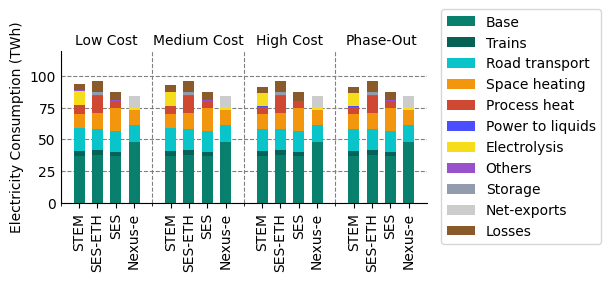

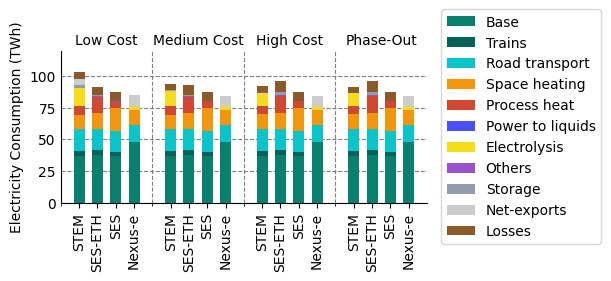

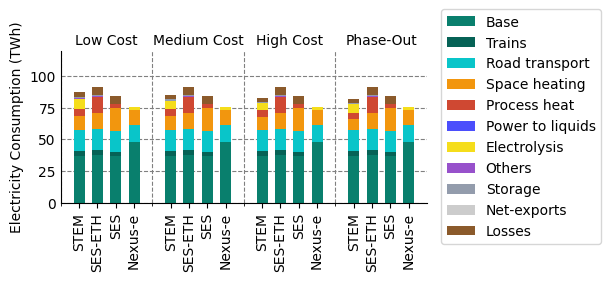

In [45]:
# Electricity consumption by use with net exports
# Available variables: https://sweet-cross.github.io/instructions-data/docs/sets/use_elec/
varList_use_net = [
    {'name':'Base','data':['elec_appliances'],'color':'#097F6D'},
    {'name':'Trains','data':['rail'],'color':'#066256'},
    {'name':'Road transport','data':['passenger', 'freight_road'],'color':'#09c5c9'},
    {'name':'Space heating','data':['space_heating'],'color':'#F2960E'},
    {'name':'Process heat','data':['process_heat'],'color':'#CF4832'},
    {'name':'Power to liquids','data':['power_to_liquid'],'color':'#4B4EFC'},
    {'name':'Electrolysis','data':['electrolysis'],'color':'#F5DD1B'},
    #{'name': 'Data centers', 'data': ['data_centers'], 'color': '#4A90E2'},
    {'name':'Others','data':['dac'],'color':'#9751CB'},
    {'name':'Storage','data':['net_storage_in'],'color':'#939CAC'},
    {'name':'Net-exports','data':['net_exports'],'color':'#CCCCCC'},
    {'name':'Losses','data':['grid_losses','storage_losses'],'color':'#8B5A2B'}
    ]

varName = 'electricity_consumption'
listModels = cross_plots.modelsid
scale = 1
xlabel = 'Electricity Consumption (TWh)'
xmax = 120
fileName = 'elecUse_net'
year = 2050

scenario_list={
    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-low','wacc_5'):'Low Cost',
        ('abroad-res-medium','wacc_5'):'Medium Cost',
        ('abroad-res-high','wacc_5'):'High Cost',
        ('abroad-res-phaseout','wacc_5'):'Phase-Out',

    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-low','wacc_5'):'Low Cost',
        ('abroad-resnuc-medium','wacc_5'):'Medium Cost',
        ('abroad-resnuc-high','wacc_5'):'High Cost',
        ('abroad-resnuc-phaseout','wacc_5'):'Phase-Out',

    },
    'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-low','wacc_5'):'Low Cost',
        ('abroad-nores-medium','wacc_5'):'Medium Cost',
        ('abroad-nores-high','wacc_5'):'High Cost',
        ('abroad-nores-phaseout','wacc_5'):'Phase-Out',

    },
    }


for name, scenarios in scenario_list.items():
    #cross_plots.plotBarHorizontal(
    cross_plots.plotBarVertical(
        listModelsid=listModels,
        listSce=scenarios,
        varName = varName,
        varList=varList_use_net,
        year=year,
        scale=1,
        label=xlabel,
        figmax = xmax,
        fileName = fileName+'_'+name+'wacc5',
        invert=False, legend=True, pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
    #    width=5, height=12,
        width=12, height=5,
        group_by="scenario", # 'scenario' or 'model'
        multi=False,          # <--- one plot
    )




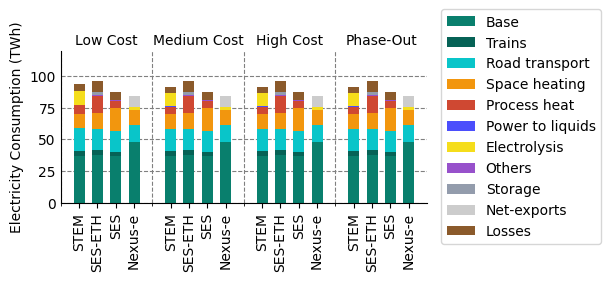

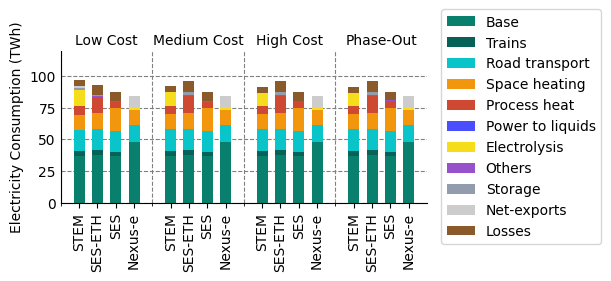

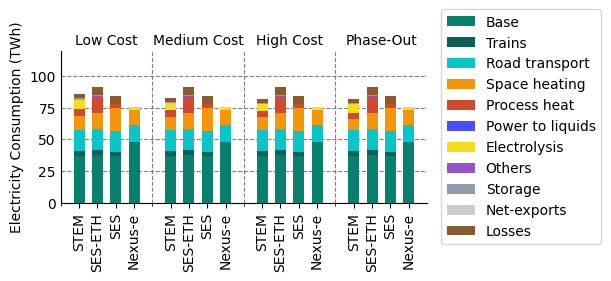

In [46]:
# Electricity consumption by use with net exports - WACC 8
# Available variables: https://sweet-cross.github.io/instructions-data/docs/sets/use_elec/
varList_use_net = [
    {'name':'Base','data':['elec_appliances'],'color':'#097F6D'},
    {'name':'Trains','data':['rail'],'color':'#066256'},
    {'name':'Road transport','data':['passenger', 'freight_road'],'color':'#09c5c9'},
    {'name':'Space heating','data':['space_heating'],'color':'#F2960E'},
    {'name':'Process heat','data':['process_heat'],'color':'#CF4832'},
    {'name':'Power to liquids','data':['power_to_liquid'],'color':'#4B4EFC'},
    {'name':'Electrolysis','data':['electrolysis'],'color':'#F5DD1B'},
  #  {'name': 'Data centers', 'data': ['data_centers'], 'color': '#4A90E2'},
    {'name':'Others','data':['dac'],'color':'#9751CB'},
    {'name':'Storage','data':['net_storage_in'],'color':'#939CAC'},
    {'name':'Net-exports','data':['net_exports'],'color':'#CCCCCC'},
    {'name':'Losses','data':['grid_losses','storage_losses'],'color':'#8B5A2B'},
 #  {'name':'Storage','data':['battery_in','phs_in'],'color':'#939CAC'},
 #  {'name':'Exports','data':['exports'],'color':'#CCCCCC'},
    ]

varName = 'electricity_consumption'
listModels = cross_plots.modelsid
scale = 1
xlabel = 'Electricity Consumption (TWh)'
xmax = 120
fileName = 'elecUse_net'
year = 2050

scenario_list={
    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-low','wacc_8'):'Low Cost',
        ('abroad-res-medium','wacc_8'):'Medium Cost',
        ('abroad-res-high','wacc_8'):'High Cost',
        ('abroad-res-phaseout','wacc_8'):'Phase-Out',

    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-low','wacc_8'):'Low Cost',
        ('abroad-resnuc-medium','wacc_8'):'Medium Cost',
        ('abroad-resnuc-high','wacc_8'):'High Cost',
        ('abroad-resnuc-phaseout','wacc_8'):'Phase-Out',

    },
    'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-low','wacc_8'):'Low Cost',
        ('abroad-nores-medium','wacc_8'):'Medium Cost',
        ('abroad-nores-high','wacc_8'):'High Cost',
        ('abroad-nores-phaseout','wacc_8'):'Phase-Out',

    },
    }


for name, scenarios in scenario_list.items():
    #cross_plots.plotBarHorizontal(
    cross_plots.plotBarVertical(
        listModelsid=listModels,
        listSce=scenarios,
        varName = varName,
        varList=varList_use_net,
        year=year,
        scale=1,
        label=xlabel,
        figmax = xmax,
        fileName = fileName+'_'+name+'wacc8',
        invert=False, legend=True, pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
    #    width=5, height=12,
        width=12, height=5,
        group_by="scenario", # 'scenario' or 'model'
        multi=False,          # <--- one plot
    )




### Capacity vs. OCC nuclear vs. WACC

['nexuse', 'ses', 'seseth', 'stem']
['#0072B2', '#E69F00', '#009E73', '#CC79A7']
True


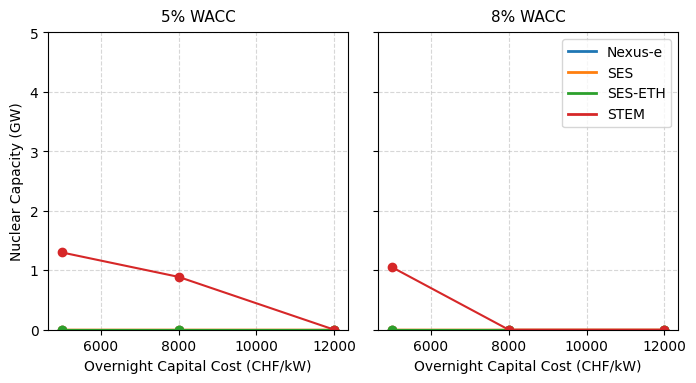

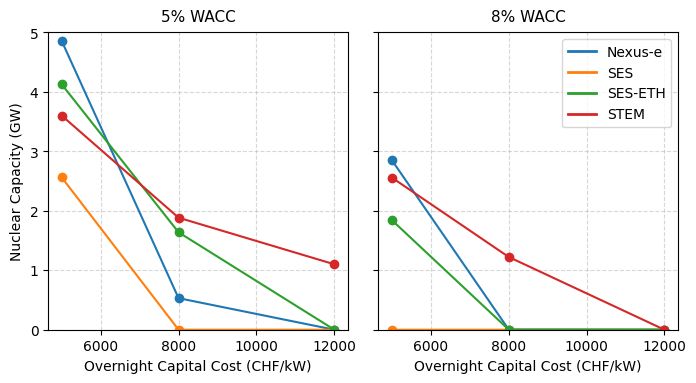

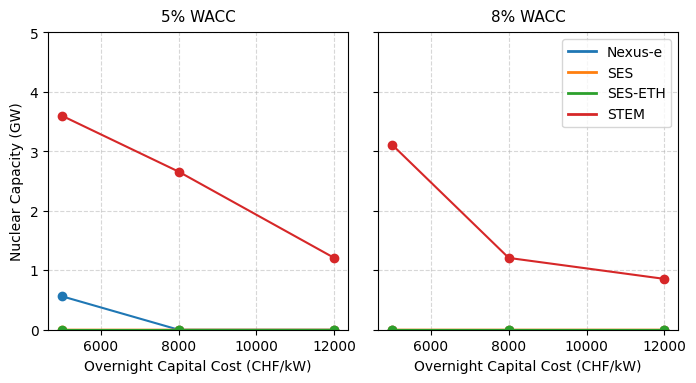

In [48]:
#### Capacity vs. cost plot


scenario_groups = {
    "res": {
        "map_sce_xaxis": {
                # ('scenario-id','variant'): 'label'
                ('abroad-res-high','wacc_5'):('wacc_5',12000),
                ('abroad-res-medium','wacc_5'):('wacc_5',8000),
                ('abroad-res-low','wacc_5'):('wacc_5',5000),
                ('abroad-res-high','wacc_8'):('wacc_8',12000),
                ('abroad-res-medium','wacc_8'):('wacc_8',8000),
                ('abroad-res-low','wacc_8'):('wacc_8',5000),

            },
        "extra_values": {
   #         ('abroad-res-high',   'wacc_8', 'nexuse'): 0.0,
   #         ('abroad-res-medium', 'wacc_8', 'nexuse'): 0.0,
   #         ('abroad-res-low',    'wacc_8', 'nexuse'): 0.0,
  #           ('abroad-res-high',   'wacc_8', 'stem'): 0.4,
  #            ('abroad-res-medium', 'wacc_8', 'stem'): 1.1,
  #            ('abroad-res-low',    'wacc_8', 'stem'): 1.4,
  #            ('abroad-res-high',   'wacc_5', 'stem'): 0.7,
  #            ('abroad-res-medium', 'wacc_5', 'stem'): 1.4,
  #            ('abroad-res-low',    'wacc_5', 'stem'): 2.4,
        },
    },
    "resnuc": {
        "map_sce_xaxis": {
                # ('scenario-id','variant')
                ('abroad-resnuc-high','wacc_5'):('wacc_5',12000),
                ('abroad-resnuc-medium','wacc_5'):('wacc_5',8000),
                ('abroad-resnuc-low','wacc_5'):('wacc_5',5000),
                ('abroad-resnuc-high','wacc_8'):('wacc_8',12000),
                ('abroad-resnuc-medium','wacc_8'):('wacc_8',8000),
                ('abroad-resnuc-low','wacc_8'):('wacc_8',5000),
            },
        "extra_values": {
    #        ('abroad-resnuc-high',   'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-resnuc-medium', 'wacc_8', 'nexuse'): 0.4,
    #        ('abroad-resnuc-low',    'wacc_8', 'nexuse'): 1.63,
    #        ('abroad-resnuc-high',   'wacc_8', 'stem'): 0.4,
    #        ('abroad-resnuc-medium', 'wacc_8', 'stem'): 1.7,
    #        ('abroad-resnuc-low',    'wacc_8', 'stem'): 2.8,
    #        ('abroad-resnuc-high',   'wacc_5', 'stem'): 1.4,
   #         ('abroad-resnuc-medium', 'wacc_5', 'stem'): 2.3,
    #        ('abroad-resnuc-low',    'wacc_5', 'stem'): 3.6,
        },
    },
    "nores": {
        "map_sce_xaxis": {
                # ('scenario-id','variant'): 'label'
                ('abroad-nores-high','wacc_5'):('wacc_5',12000),
                ('abroad-nores-medium','wacc_5'):('wacc_5',8000),
                ('abroad-nores-low','wacc_5'):('wacc_5',5000),
                ('abroad-nores-high','wacc_8'):('wacc_8',12000),
                ('abroad-nores-medium','wacc_8'):('wacc_8',8000),
                ('abroad-nores-low','wacc_8'):('wacc_8',5000),

            },
        "extra_values": {
    #        ('abroad-nores-high',   'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-nores-medium', 'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-nores-low',    'wacc_8', 'nexuse'): 0.0,
    #          ('abroad-nores-high',   'wacc_8', 'stem'): 0.8,
    #          ('abroad-nores-medium', 'wacc_8', 'stem'): 1.7,
    #          ('abroad-nores-low',    'wacc_8', 'stem'): 3.3,
   #           ('abroad-nores-high',   'wacc_5', 'stem'): 1.5,
    #          ('abroad-nores-medium', 'wacc_5', 'stem'): 3.3,
    #          ('abroad-nores-low',    'wacc_5', 'stem'): 3.6,
        },
    },
}


listModels = cross_plots.modelsid #any model can be excluded, the list should include the model ids

#Checking colors for models
print(cross_plots.modelsid)
print(cross_plots.model_colors)
print(hasattr(cross_plots, "model_colors"))


varName = 'installed_capacity'
use_technology_fuel = 'nuclear'
xlabel = 'Overnight Capital Cost (CHF/kW)'
ylabel = 'Nuclear Capacity (GW)'
fileName = 'nucCap_occ'
year = 2050

for group_name, cfg in scenario_groups.items():

    cross_plots.plotLineByScenario(
        listModelsid = listModels,
        map_sce_xaxis = cfg["map_sce_xaxis"],
        varName = varName,
        use_technology_fuel = use_technology_fuel,
        year = year,
        scale = 1, # if values are MW → GW, etc.
        xlabel = xlabel,
        ylabel = ylabel,
        fileName = fileName+'_'+group_name,
        width = 18,
        height = 10,
        ylim = (0,5),
        extra_values   = cfg["extra_values"],
        ncols=2,
        subplot_titles=["5% WACC", "8% WACC"],
        show_point_labels=False
    )


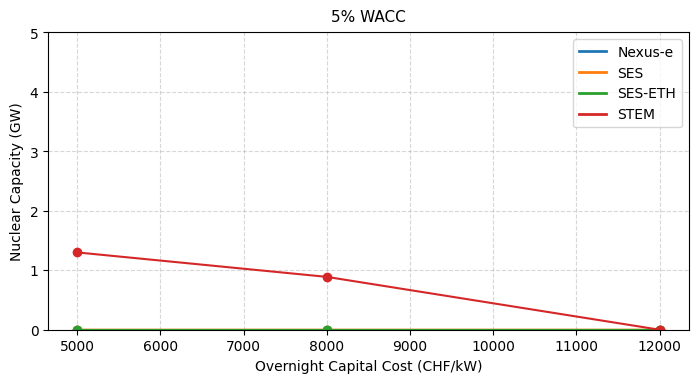

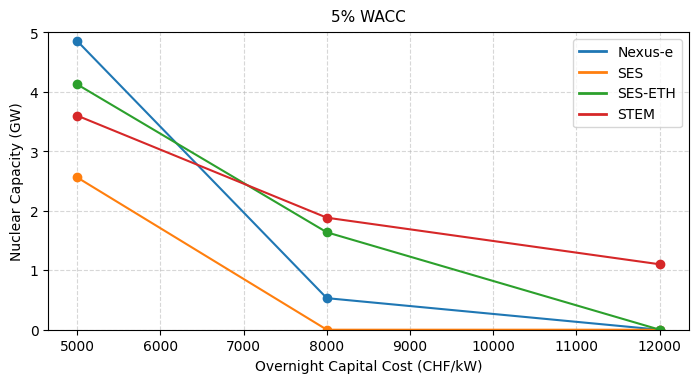

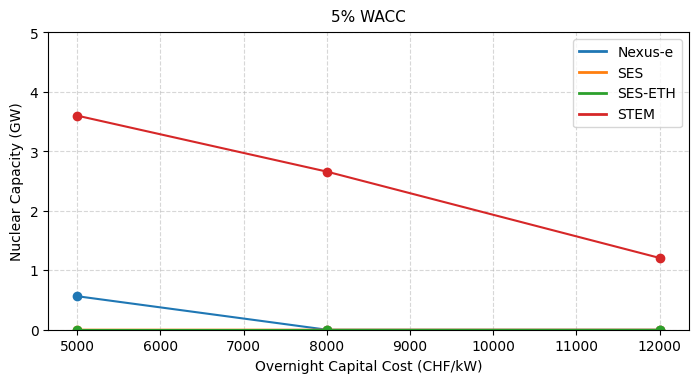

In [ ]:
#### Capacity vs. cost plot %5 WACC


scenario_groups = {
    "res": {
        "map_sce_xaxis": {
                # ('scenario-id','variant'): 'label'
                ('abroad-res-high','wacc_5'):('wacc_5',12000),
                ('abroad-res-medium','wacc_5'):('wacc_5',8000),
                ('abroad-res-low','wacc_5'):('wacc_5',5000),
           #     ('abroad-res-high','wacc_8'):('wacc_8',12000),
           #     ('abroad-res-medium','wacc_8'):('wacc_8',8000),
           #     ('abroad-res-low','wacc_8'):('wacc_8',5000),

            },
        "extra_values": {
   #         ('abroad-res-high',   'wacc_8', 'nexuse'): 0.0,
   #         ('abroad-res-medium', 'wacc_8', 'nexuse'): 0.0,
   #         ('abroad-res-low',    'wacc_8', 'nexuse'): 0.0,
  #           ('abroad-res-high',   'wacc_8', 'stem'): 0.4,
  #            ('abroad-res-medium', 'wacc_8', 'stem'): 1.1,
  #            ('abroad-res-low',    'wacc_8', 'stem'): 1.4,
  #            ('abroad-res-high',   'wacc_5', 'stem'): 0.7,
  #            ('abroad-res-medium', 'wacc_5', 'stem'): 1.4,
  #            ('abroad-res-low',    'wacc_5', 'stem'): 2.4,
        },
    },
    "resnuc": {
        "map_sce_xaxis": {
                # ('scenario-id','variant')
                ('abroad-resnuc-high','wacc_5'):('wacc_5',12000),
                ('abroad-resnuc-medium','wacc_5'):('wacc_5',8000),
                ('abroad-resnuc-low','wacc_5'):('wacc_5',5000),
           #    ('abroad-resnuc-high','wacc_8'):('wacc_8',12000),
           #    ('abroad-resnuc-medium','wacc_8'):('wacc_8',8000),
           #     ('abroad-resnuc-low','wacc_8'):('wacc_8',5000),
            },
        "extra_values": {
    #        ('abroad-resnuc-high',   'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-resnuc-medium', 'wacc_8', 'nexuse'): 0.4,
    #        ('abroad-resnuc-low',    'wacc_8', 'nexuse'): 1.63,
    #        ('abroad-resnuc-high',   'wacc_8', 'stem'): 0.4,
    #        ('abroad-resnuc-medium', 'wacc_8', 'stem'): 1.7,
    #        ('abroad-resnuc-low',    'wacc_8', 'stem'): 2.8,
    #        ('abroad-resnuc-high',   'wacc_5', 'stem'): 1.4,
   #         ('abroad-resnuc-medium', 'wacc_5', 'stem'): 2.3,
    #        ('abroad-resnuc-low',    'wacc_5', 'stem'): 3.6,
        },
    },
    "nores": {
        "map_sce_xaxis": {
                # ('scenario-id','variant'): 'label'
                ('abroad-nores-high','wacc_5'):('wacc_5',12000),
                ('abroad-nores-medium','wacc_5'):('wacc_5',8000),
                ('abroad-nores-low','wacc_5'):('wacc_5',5000),
             #   ('abroad-nores-high','wacc_8'):('wacc_8',12000),
             #   ('abroad-nores-medium','wacc_8'):('wacc_8',8000),
             #   ('abroad-nores-low','wacc_8'):('wacc_8',5000),

            },
        "extra_values": {
    #        ('abroad-nores-high',   'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-nores-medium', 'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-nores-low',    'wacc_8', 'nexuse'): 0.0,
    #          ('abroad-nores-high',   'wacc_8', 'stem'): 0.8,
    #          ('abroad-nores-medium', 'wacc_8', 'stem'): 1.7,
    #          ('abroad-nores-low',    'wacc_8', 'stem'): 3.3,
   #           ('abroad-nores-high',   'wacc_5', 'stem'): 1.5,
    #          ('abroad-nores-medium', 'wacc_5', 'stem'): 3.3,
    #          ('abroad-nores-low',    'wacc_5', 'stem'): 3.6,
        },
    },
}


listModels = cross_plots.modelsid #any model can be excluded, the list should include the model ids
varName = 'installed_capacity'
use_technology_fuel = 'nuclear'
xlabel = 'Overnight Capital Cost (CHF/kW)'
ylabel = 'Nuclear Capacity (GW)'
fileName = 'nucCap_occ'
year = 2050



for group_name, cfg in scenario_groups.items():

    cross_plots.plotLineByScenario(
        listModelsid = listModels,
        map_sce_xaxis = cfg["map_sce_xaxis"],
        varName = varName,
        use_technology_fuel = use_technology_fuel,
        year = year,
        scale = 1,  # if values are MW → GW, etc.
        xlabel = xlabel,
        ylabel = ylabel,
        fileName = fileName+'_'+group_name+'_wacc5',
        width = 18,
        height = 10,
        ylim = (0,5),
        extra_values        = cfg["extra_values"],
        show_point_labels=False,
        subplot_titles=["5% WACC"]
    )

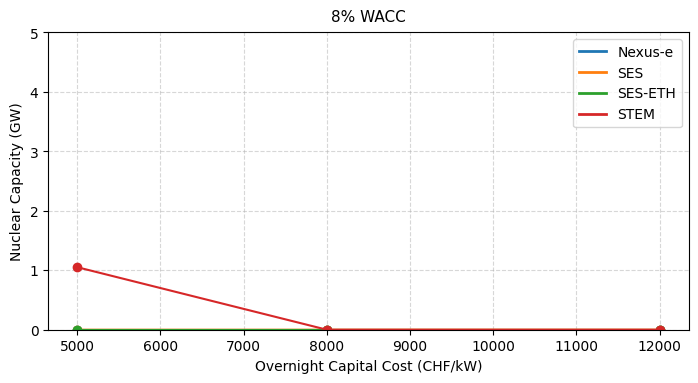

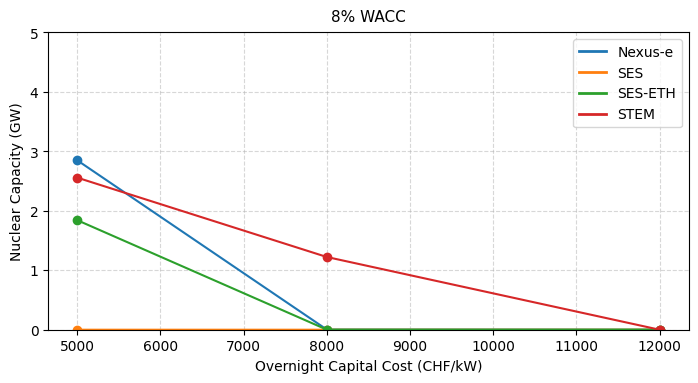

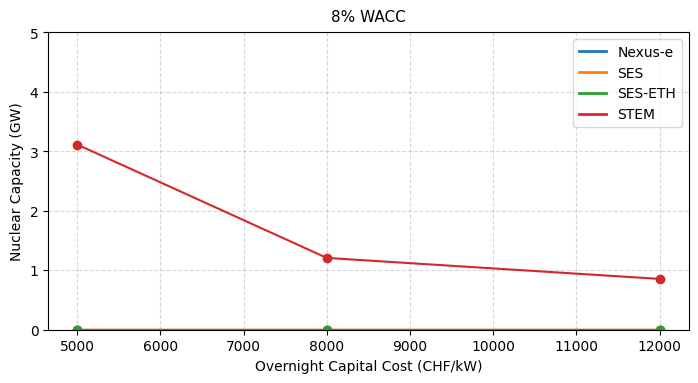

In [ ]:
#### Capacity vs. cost plot 8% WACC


scenario_groups = {
    "res": {
        "map_sce_xaxis": {
                # ('scenario-id','variant'): 'label'
         #       ('abroad-res-high','wacc_5'):('wacc_5',12000),
         #       ('abroad-res-medium','wacc_5'):('wacc_5',8000),
          #      ('abroad-res-low','wacc_5'):('wacc_5',5000),
                ('abroad-res-high','wacc_8'):('wacc_8',12000),
                ('abroad-res-medium','wacc_8'):('wacc_8',8000),
                ('abroad-res-low','wacc_8'):('wacc_8',5000),

            },
        "extra_values": {
   #         ('abroad-res-high',   'wacc_8', 'nexuse'): 0.0,
   #         ('abroad-res-medium', 'wacc_8', 'nexuse'): 0.0,
   #         ('abroad-res-low',    'wacc_8', 'nexuse'): 0.0,
  #           ('abroad-res-high',   'wacc_8', 'stem'): 0.4,
  #            ('abroad-res-medium', 'wacc_8', 'stem'): 1.1,
  #            ('abroad-res-low',    'wacc_8', 'stem'): 1.4,
  #            ('abroad-res-high',   'wacc_5', 'stem'): 0.7,
  #            ('abroad-res-medium', 'wacc_5', 'stem'): 1.4,
  #            ('abroad-res-low',    'wacc_5', 'stem'): 2.4,
        },
    },
    "resnuc": {
        "map_sce_xaxis": {
                # ('scenario-id','variant')
          #      ('abroad-resnuc-high','wacc_5'):('wacc_5',12000),
           #     ('abroad-resnuc-medium','wacc_5'):('wacc_5',8000),
           #     ('abroad-resnuc-low','wacc_5'):('wacc_5',5000),
               ('abroad-resnuc-high','wacc_8'):('wacc_8',12000),
               ('abroad-resnuc-medium','wacc_8'):('wacc_8',8000),
                ('abroad-resnuc-low','wacc_8'):('wacc_8',5000),
            },
        "extra_values": {
    #        ('abroad-resnuc-high',   'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-resnuc-medium', 'wacc_8', 'nexuse'): 0.4,
    #        ('abroad-resnuc-low',    'wacc_8', 'nexuse'): 1.63,
    #        ('abroad-resnuc-high',   'wacc_8', 'stem'): 0.4,
    #        ('abroad-resnuc-medium', 'wacc_8', 'stem'): 1.7,
    #        ('abroad-resnuc-low',    'wacc_8', 'stem'): 2.8,
    #        ('abroad-resnuc-high',   'wacc_5', 'stem'): 1.4,
   #         ('abroad-resnuc-medium', 'wacc_5', 'stem'): 2.3,
    #        ('abroad-resnuc-low',    'wacc_5', 'stem'): 3.6,
        },
    },
    "nores": {
        "map_sce_xaxis": {
                # ('scenario-id','variant'): 'label'
             #   ('abroad-nores-high','wacc_5'):('wacc_5',12000),
             #   ('abroad-nores-medium','wacc_5'):('wacc_5',8000),
             #   ('abroad-nores-low','wacc_5'):('wacc_5',5000),
                ('abroad-nores-high','wacc_8'):('wacc_8',12000),
                ('abroad-nores-medium','wacc_8'):('wacc_8',8000),
                ('abroad-nores-low','wacc_8'):('wacc_8',5000),

            },
        "extra_values": {
    #        ('abroad-nores-high',   'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-nores-medium', 'wacc_8', 'nexuse'): 0.0,
    #        ('abroad-nores-low',    'wacc_8', 'nexuse'): 0.0,
    #          ('abroad-nores-high',   'wacc_8', 'stem'): 0.8,
    #          ('abroad-nores-medium', 'wacc_8', 'stem'): 1.7,
    #          ('abroad-nores-low',    'wacc_8', 'stem'): 3.3,
   #           ('abroad-nores-high',   'wacc_5', 'stem'): 1.5,
    #          ('abroad-nores-medium', 'wacc_5', 'stem'): 3.3,
    #          ('abroad-nores-low',    'wacc_5', 'stem'): 3.6,
        },
    },
}


listModels = cross_plots.modelsid #any model can be excluded, the list should include the model ids
varName = 'installed_capacity'
use_technology_fuel = 'nuclear'
xlabel = 'Overnight Capital Cost (CHF/kW)'
ylabel = 'Nuclear Capacity (GW)'
fileName = 'nucCap_occ'
year = 2050



for group_name, cfg in scenario_groups.items():

    cross_plots.plotLineByScenario(
        listModelsid = listModels,
        map_sce_xaxis = cfg["map_sce_xaxis"],
        varName = varName,
        use_technology_fuel = use_technology_fuel,
        year = year,
        scale = 1,  # if values are MW → GW, etc.
        xlabel = xlabel,
        ylabel = ylabel,
        fileName = fileName+'_'+group_name+'_wacc8',
        width = 18,
        height = 10,
        ylim = (0,5),
        extra_values        = cfg["extra_values"],
        show_point_labels=False,
        subplot_titles=["8% WACC"]
    )

### Hydrogen Production

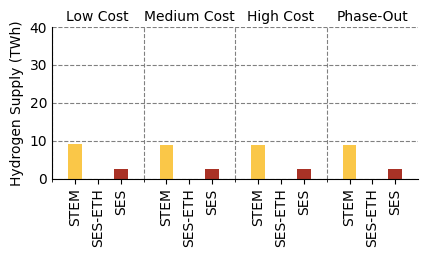

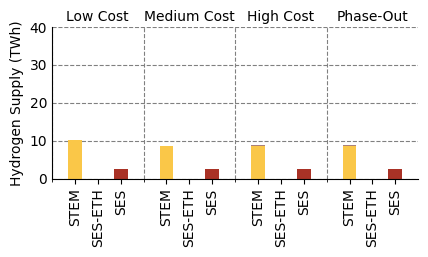

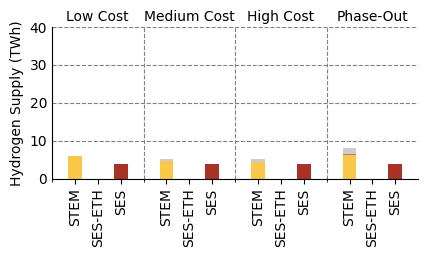

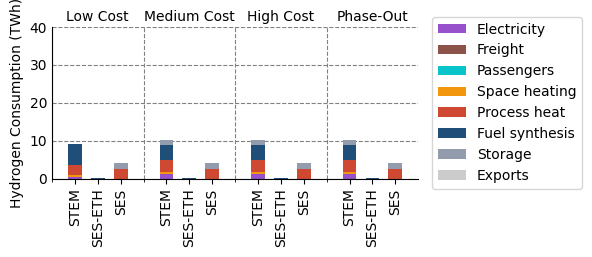

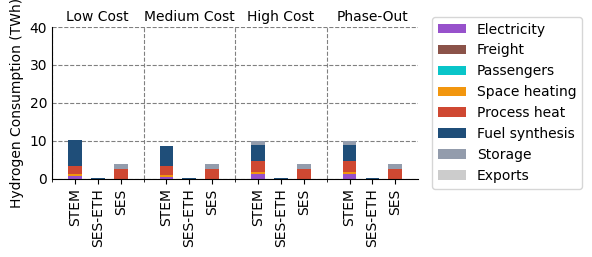

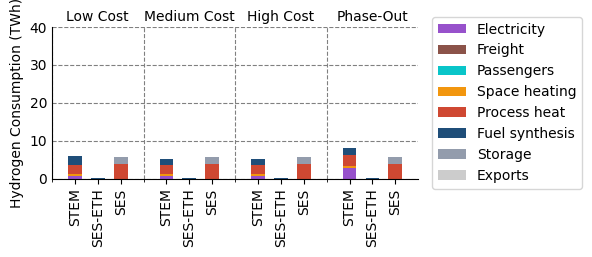

In [ ]:
# Hydrogen supply by technology https://sweet-cross.github.io/instructions-data/docs/sets/tech_hydrogen/
varList_h2_supply = [
    {'name':'Electrolysis','data':['electrolyser'],'color':'#FAC748'},
    {'name':'Steam reforming','data':['steam_reforming'],'color':'#1f6228'},
    {'name':'Gasification','data':['wood_gasification_h2','waste_gasification_h2'],'color':'#a9807c'},
    {'name':'Pyrolysis','data':['methane_pyrolysis'],'color':'#A93226'},
    {'name':'Imports','data':['imports'],'color':'#CCCCCC'}
    ]

varName = 'h2_supply'
listModels = cross_plots.modelsid
xlabel = 'Hydrogen Supply (TWh)'
xmax = 40
fileName = 'h2Supply_tech'
year = 2050

for name, scenarios in scenario_list.items():
    #cross_plots.plotBarHorizontal(
    cross_plots.plotBarVertical(
        listModelsid=['ses','seseth', 'stem'],
        listSce=scenarios,
        varName = varName,
        varList=varList_h2_supply,
        year=year,
        scale=1,
        label=xlabel,
        figmax = xmax,
        fileName = fileName+'_'+name,
        invert=False, legend=False, pos_legend="upper right",
    #    width=5, height=12,
        width=12, height=5,
        group_by="scenario", # 'scenario' or 'model'
        multi=False,          # <--- one plot
    )


varList_h2_consump = [
    {'name':'Electricity','data':['hydrogen_pp','fuel_cell_h2'],'color':'#9751CB'},
    {'name':'Freight','data':['truck','ldv'],'color':'#8B5349'},
    {'name':'Passengers','data':['passenger_road_public','passenger_road_private'],'color':'#09c5c9'},
    {'name':'Space heating','data':['space_heating'],'color':'#F2960E'},
    {'name':'Process heat','data':['process_heat'],'color':'#CF4832'},
    {'name':'Fuel synthesis','data':['fuel_synthesis'],'color':'#1F4E79'},
     {'name':'Storage','data':['storage'],'color':'#939CAC'},
    {'name':'Exports','data':['exports'],'color':'#CCCCCC'}
    ]

varName = 'h2_fec'
listModels = cross_plots.modelsid
scale = 1
xlabel = 'Hydrogen Consumption (TWh)'
xmax = 40
fileName = 'h2Use'
year = 2050
for name, scenarios in scenario_list.items():
    #cross_plots.plotBarHorizontal(
    cross_plots.plotBarVertical(
        listModelsid=['ses','seseth','stem'],
        listSce=scenarios,
        varName = varName,
        varList=varList_h2_consump,
        year=year,
        scale=1,
        label=xlabel,
        figmax = xmax,
        fileName = fileName+'_'+name,
        invert=False, legend=True, pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
    #    width=5, height=12,
        width=12, height=5,
        group_by="scenario", # 'scenario' or 'model'
        multi=False,          # <--- one plot
    )

Within Model System Costs Changes

In [ ]:
#Calculate relative cost changes
varName ='total_system_costs'

listModels = cross_plots.modelsid
year=2050

# Get only the costs from the annual data
costs = cross_plots.annualData.loc[(slice(None),slice(None),slice(None),varName,'','annual',year)]
# Reshape the dataframe so we have one scenario variant per column
costs = costs.unstack(level=[1,0]).droplevel(level=0,axis=1)
costs_change = costs.copy()

variant_list = ['wacc_5','wacc_8']

scenario_groups = {
'res': {'base': 'abroad-res-phaseout','compare': ['abroad-res-low','abroad-res-medium','abroad-res-high']},
'resnuc': {'base': 'abroad-resnuc-phaseout','compare': ['abroad-resnuc-low','abroad-resnuc-medium','abroad-resnuc-high']},
'nores': {'base': 'abroad-nores-phaseout','compare': ['abroad-nores-low','abroad-nores-medium','abroad-nores-high']},
}

for variant in variant_list:
  for name, scenarios in scenario_groups.items():
    base_scenario = scenarios['base']
    cost_base = costs.loc[:,(variant,base_scenario)]
    costs_change.loc[:,(variant,base_scenario)] = 0
    for s in scenarios['compare']:
      costs_change.loc[:,(variant,s)] = (costs_change.loc[:,(variant,s)]-cost_base)
      #costs_change.loc[:,(variant,s)] = ((costs_change.loc[:,(variant,s)]-cost_base)/cost_base)*100


# # Checks
# print("Checks")
# for variant in variant_list:
#   for comp_scenario in scenarios['compare']:
#     print(f"Variant: {variant}, Scenario: {comp_scenario}")
#     check = - costs.loc[:, (variant, base_scenario)] + costs.loc[:, (variant, comp_scenario)]
#     print(costs_change.loc[:, (variant, comp_scenario)] - check)


print(costs_change)
# Export to csv
costs_change.to_csv('cost_change.csv')

scenario_variant            wacc_5            wacc_8           wacc_5  \
scenario_name    abroad-nores-high abroad-nores-high abroad-nores-low   
model                                                                   
ses                      -0.001073         -0.001488        -0.001150   
seseth                    0.000375          0.000587        -0.000278   
stem                     -0.891819         -0.645376        -2.227040   

scenario_variant           wacc_8              wacc_5              wacc_8  \
scenario_name    abroad-nores-low abroad-nores-medium abroad-nores-medium   
model                                                                       
ses                     -0.000171           -0.001169           -0.001477   
seseth                  -0.000441            0.000000            0.000000   
stem                    -1.845423           -1.576875           -1.207799   

scenario_variant                wacc_5                wacc_8          wacc_5  \
scenario_name    a

### Liquids use - Bar plot by model and use

In [ ]:
# Liquids consumption by use https://sweet-cross.github.io/instructions-data/docs/sets/use_liquids/

varList_liquids_consump = [
    {'name':'Electricity','data':['elec_generation'],'color':'#9751CB'},
    {'name':'Freight','data':['truck','ldv'],'color':'#8B5349'},
    {'name':'Passengers','data':['passenger_road_public','passenger_road_private'],'color':'#09c5c9'},
    {'name':'Space heating','data':['space_heating'],'color':'#F2960E'},
    {'name':'Process heat','data':['process_heat'],'color':'#CF4832'},
    {'name':'Fuel syntheis','data':['fuel_synthesis'],'color':'#1F4E79'},
     {'name':'Storage','data':['storage'],'color':'#939CAC'},
    {'name':'Exports','data':['exports'],'color':'#CCCCCC'}
    ]

varName = 'liquids_fec'
listModels = cross_plots.modelsid
scale = 1
xlabel = 'Liquid fuels (TWh)'
xmax = 50
fileName = 'liquidsUse.pdf'
right = True #True if model names have to go on the right, it invers the axis
legend = True # True if legend has to be displayed
pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
onTopVarName = ''
year = '2050'
height=15
width=7
# plotBar() is not available anymore, see the different methods starting with plotBar
# cross_plots.plotBar(listModels,varName,varList_liquids_consump,year,scale,xlabel,xmax,fileName,right,legend,pos_legend,onTopVarName,width,height)


## Electricity Imports

res


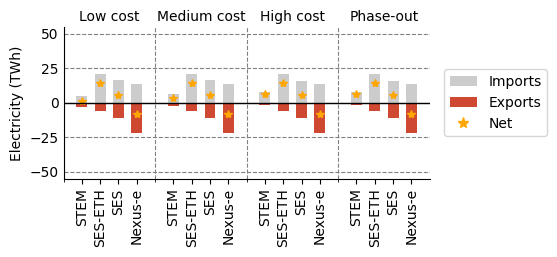

resnuc


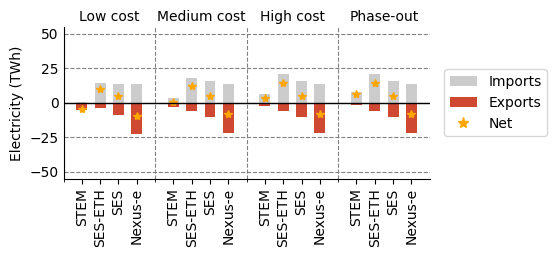

nores


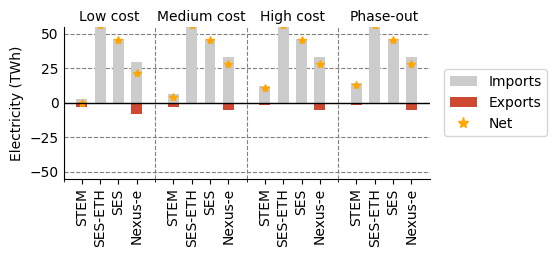

In [ ]:
#### Imports and exports -- wacc 5
fileName = 'elec_imports'
year = 2050

signedVarList = [
    {
        "name": "Imports",
        "varName": "electricity_supply",
        "techs": ["imports"],
        "sign": +1,
        "color": "#cccccc",
    },
    {
        "name": "Exports",
        "varName": "electricity_consumption",
        "techs": ["exports"],
        "sign": -1,
        "color": "#CF4832",
    },
]

scenario_list={

    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-low','wacc_5'):'Low cost',
        ('abroad-res-medium','wacc_5'):'Medium cost',
        ('abroad-res-high','wacc_5'):'High cost',
        ('abroad-res-phaseout','wacc_5'):'Phase-out',


    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-low','wacc_5'):'Low cost',
        ('abroad-resnuc-medium','wacc_5'):'Medium cost',
        ('abroad-resnuc-high','wacc_5'):'High cost',
        ('abroad-resnuc-phaseout','wacc_5'):'Phase-out',
    },
        'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-low','wacc_5'):'Low cost',
        ('abroad-nores-medium','wacc_5'):'Medium cost',
        ('abroad-nores-high','wacc_5'):'High cost',
        ('abroad-nores-phaseout','wacc_5'):'Phase-out',
    },
    }

for name, scenarios in scenario_list.items():
    print(name)
    cross_plots.plotBarVerticalSigned(
        listModelsid=listModels,
        listSce=scenarios,
        signedVarList=signedVarList,
        year=year,
        scale=1,
        label="Electricity (TWh)",
        figmax=55,
        fileName=fileName+"_"+name+'wacc5',
        invert=False,
        legend=True,
        #pos_legend="upper right",
        pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
        width=12,
        height=5,
        group_by="scenario",  # or "model"
        multi=False,
    )

res


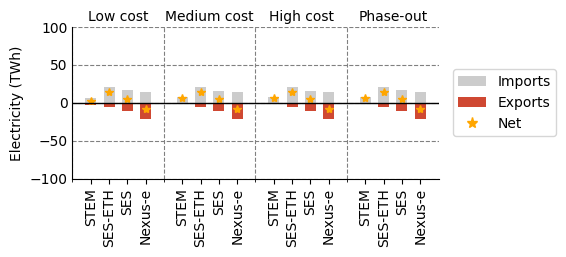

resnuc


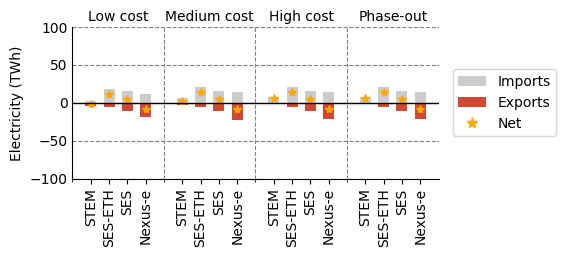

nores


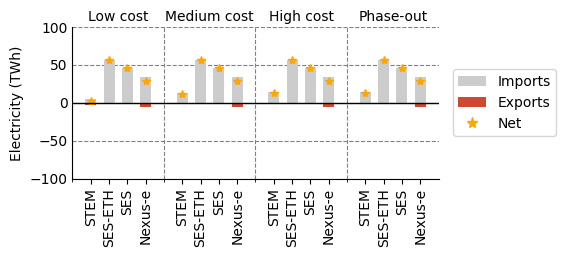

In [ ]:
#### Imports and exports -- wacc 8
fileName = 'elec_imports'
year = 2050

signedVarList = [
    {
        "name": "Imports",
        "varName": "electricity_supply",
        "techs": ["imports"],
        "sign": +1,
        "color": "#cccccc",
    },
    {
        "name": "Exports",
        "varName": "electricity_consumption",
        "techs": ["exports"],
        "sign": -1,
        "color": "#CF4832",
    },
]

scenario_list={

    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-low','wacc_8'):'Low cost',
        ('abroad-res-medium','wacc_8'):'Medium cost',
        ('abroad-res-high','wacc_8'):'High cost',
        ('abroad-res-phaseout','wacc_8'):'Phase-out',
    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-low','wacc_8'):'Low cost',
        ('abroad-resnuc-medium','wacc_8'):'Medium cost',
        ('abroad-resnuc-high','wacc_8'):'High cost',
        ('abroad-resnuc-phaseout','wacc_8'):'Phase-out',
    },
        'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-low','wacc_8'):'Low cost',
        ('abroad-nores-medium','wacc_8'):'Medium cost',
        ('abroad-nores-high','wacc_8'):'High cost',
        ('abroad-nores-phaseout','wacc_8'):'Phase-out',
    },
    }

for name, scenarios in scenario_list.items():
    print(name)
    cross_plots.plotBarVerticalSigned(
        listModelsid=listModels,
        listSce=scenarios,
        signedVarList=signedVarList,
        year=year,
        scale=1,
        label="Electricity (TWh)",
        figmax=100,
        fileName=fileName+"_"+name+'wacc8',
        invert=False,
        legend=True,
        #pos_legend="upper right",
        pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
        width=12,
        height=5,
        group_by="scenario",  # or "model"
        multi=False,
    )

## Seasonal Trade

### With season as argument

res


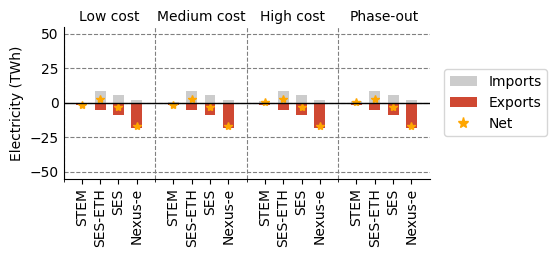

resnuc


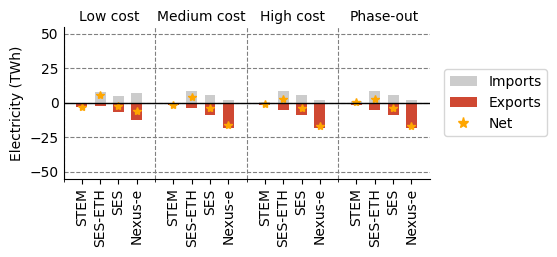

nores


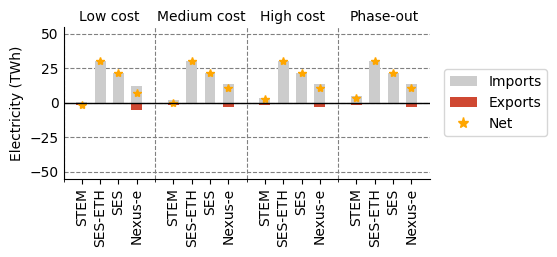

In [ ]:
#### Summer imports and exports -- wacc 5
year = 2050
wacc: Literal[5, 8] = 5
season: Literal["summer", "winter"] = "summer"
fileName = f"seasonal_trade_{season}"

signedVarList = [
    {
        "name": "Imports",
        "varName": "electricity_supply",
        "techs": [f"{season}_imports"],
        "sign": +1,
        "color": "#cccccc",
    },
    {
        "name": "Exports",
        "varName": "electricity_consumption",
        "techs": [f"{season}_exports"],
        "sign": -1,
        "color": "#CF4832",
    },
]

scenario_list={

    'res': {
        # ('scenario-id','variant'): 'label'
        ('abroad-res-low',f"wacc_{wacc}"):'Low cost',
        ('abroad-res-medium',f"wacc_{wacc}"):'Medium cost',
        ('abroad-res-high',f"wacc_{wacc}"):'High cost',
        ('abroad-res-phaseout',f"wacc_{wacc}"):'Phase-out',


    },
    'resnuc': {
        # ('scenario-id','variant'): 'label'
        ('abroad-resnuc-low',f"wacc_{wacc}"):'Low cost',
        ('abroad-resnuc-medium',f"wacc_{wacc}"):'Medium cost',
        ('abroad-resnuc-high',f"wacc_{wacc}"):'High cost',
        ('abroad-resnuc-phaseout',f"wacc_{wacc}"):'Phase-out',
    },
        'nores': {
        # ('scenario-id','variant'): 'label'
        ('abroad-nores-low',f"wacc_{wacc}"):'Low cost',
        ('abroad-nores-medium',f"wacc_{wacc}"):'Medium cost',
        ('abroad-nores-high',f"wacc_{wacc}"):'High cost',
        ('abroad-nores-phaseout',f"wacc_{wacc}"):'Phase-out',
    },
    }

for name, scenarios in scenario_list.items():
    print(name)
    cross_plots.plotBarVerticalSigned(
        listModelsid=listModels,
        listSce=scenarios,
        signedVarList=signedVarList,
        year=year,
        scale=1,
        label="Electricity (TWh)",
        figmax=55,
        fileName=fileName+"_"+name+f"wacc{wacc}",
        invert=False,
        legend=True,
        #pos_legend="upper right",
        pos_legend={# This puts the legend outside-right for vertical plots
                "loc": "center left",
                "bbox_to_anchor": (1.02, 0.5),
                },
        width=12,
        height=5,
        group_by="scenario",  # or "model"
        multi=False,
    )

### With season panels

res


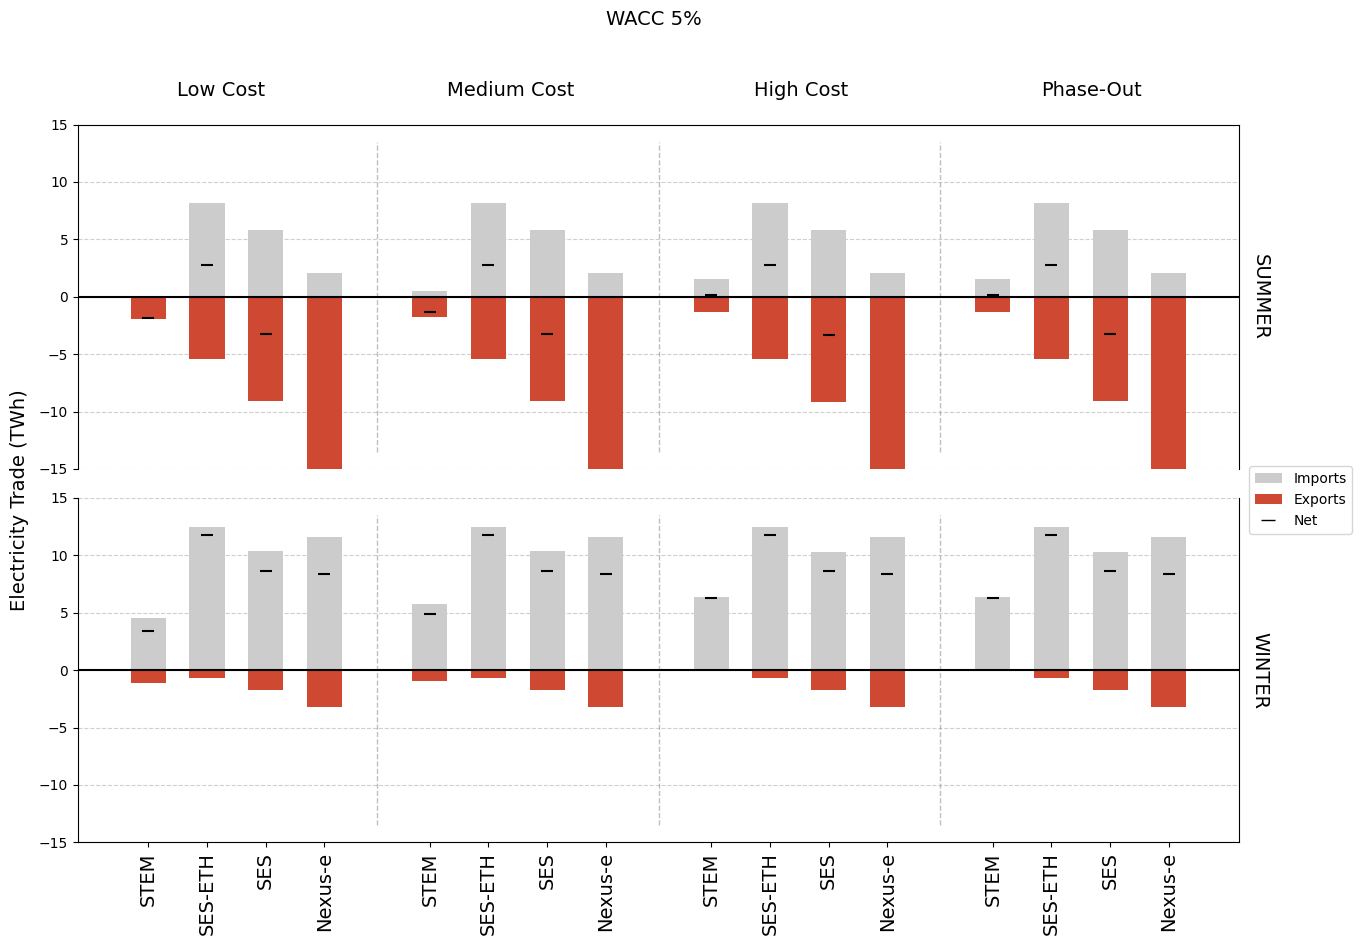

resnuc


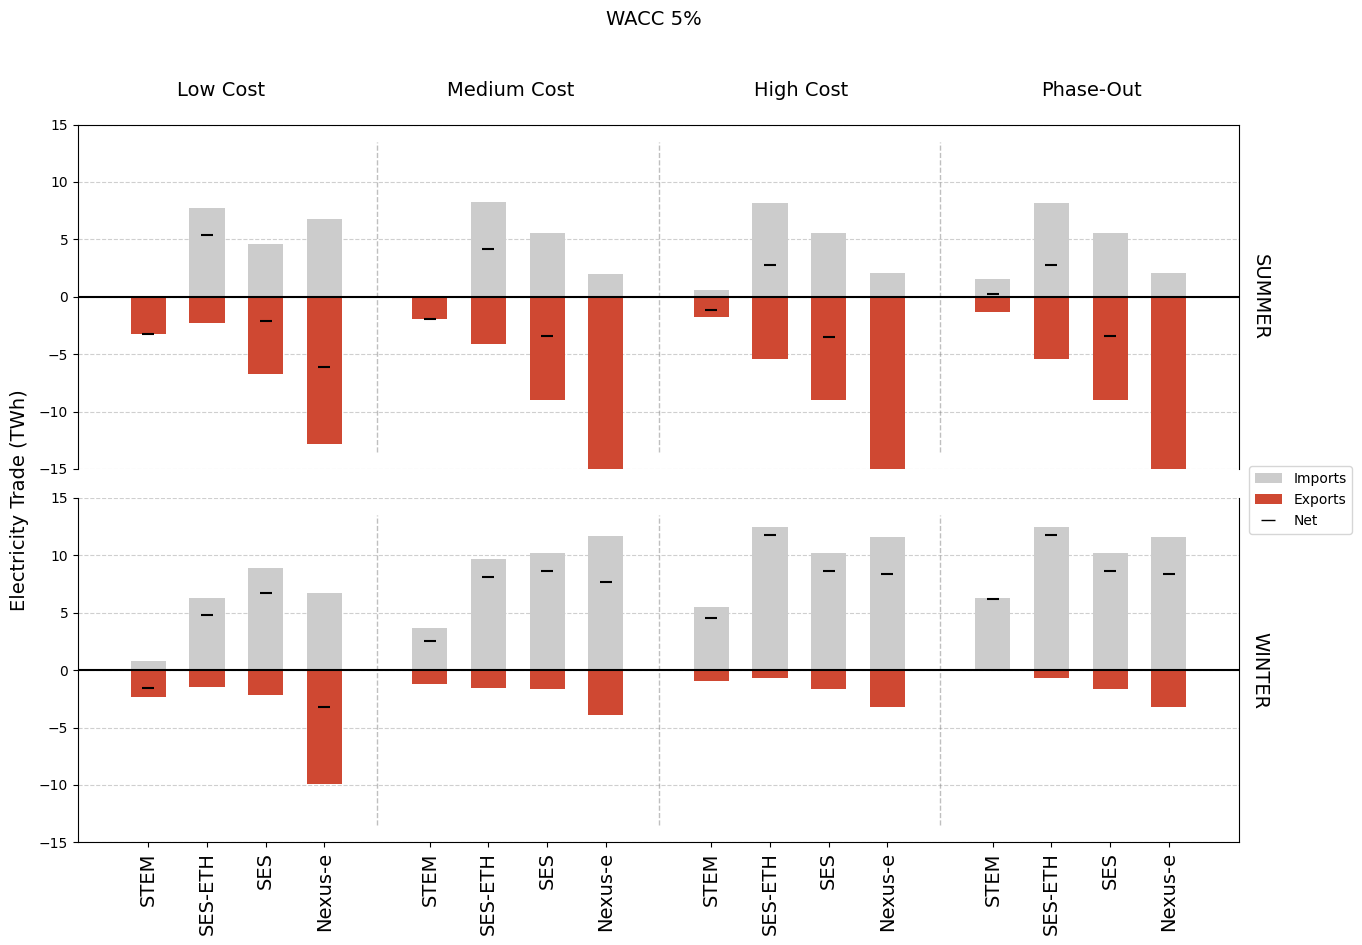

nores


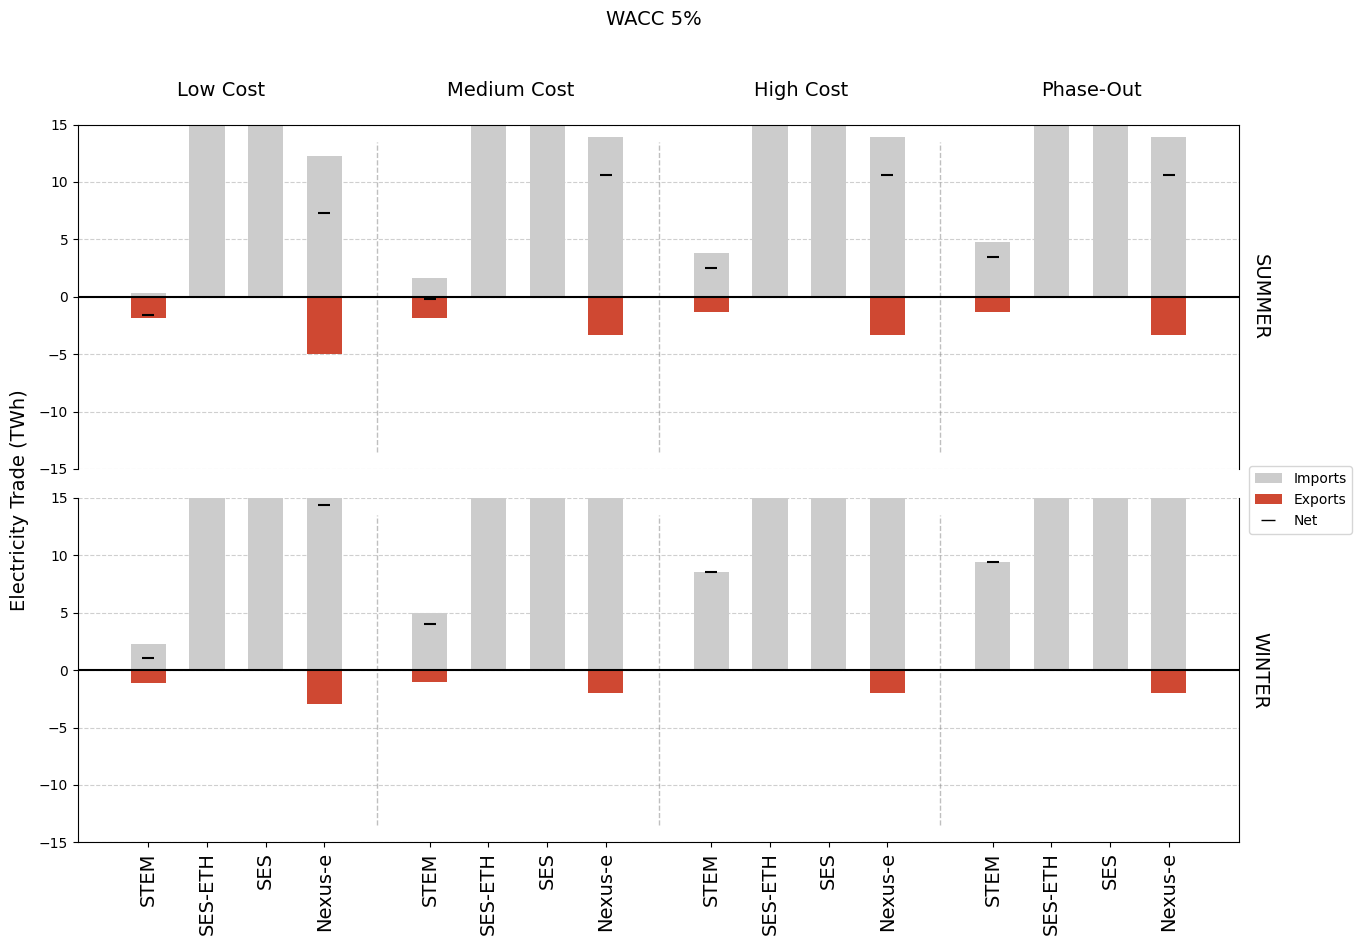

res


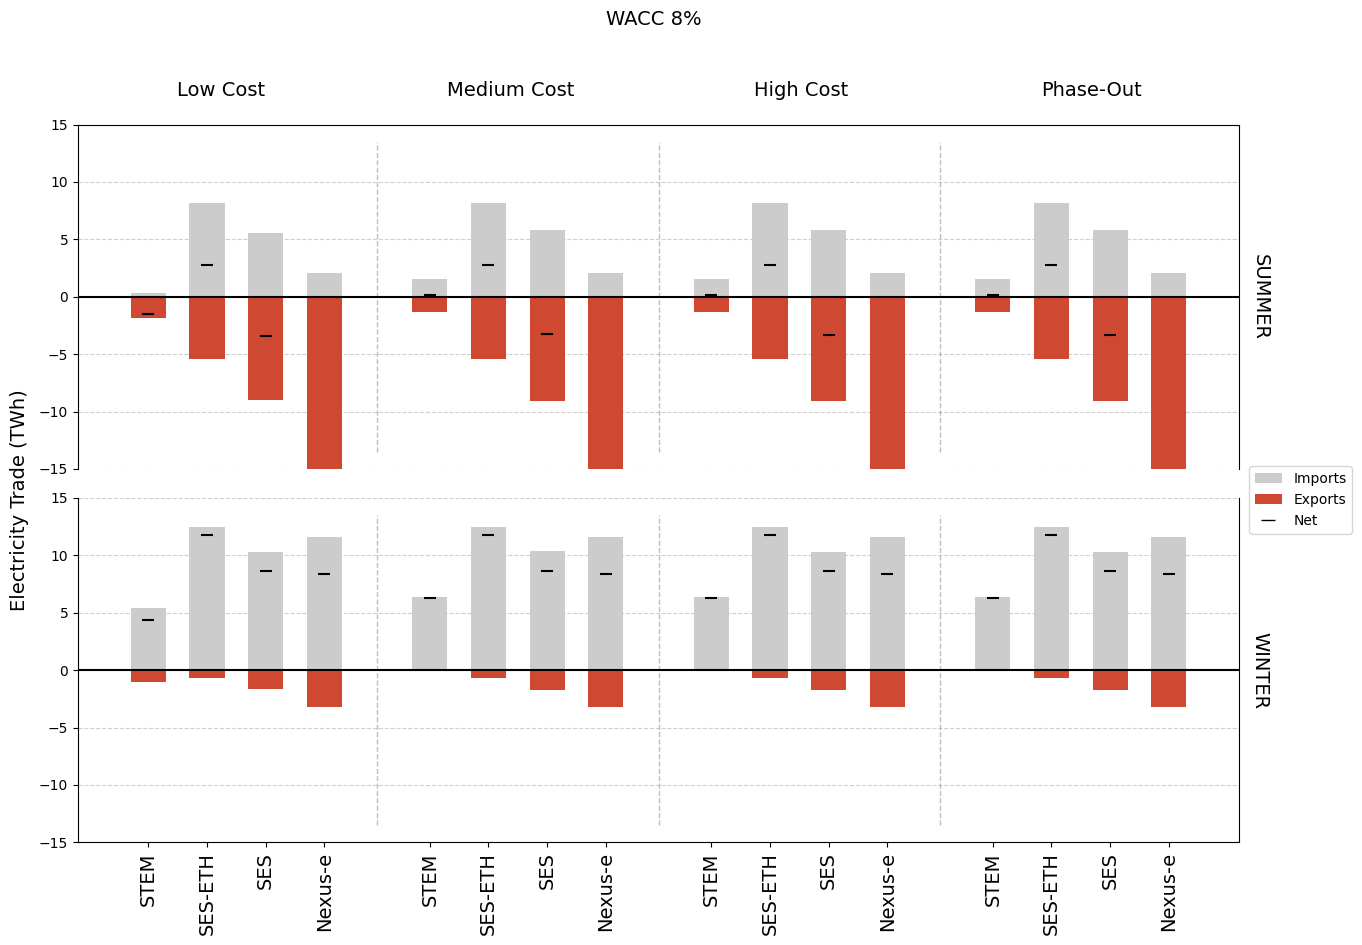

resnuc


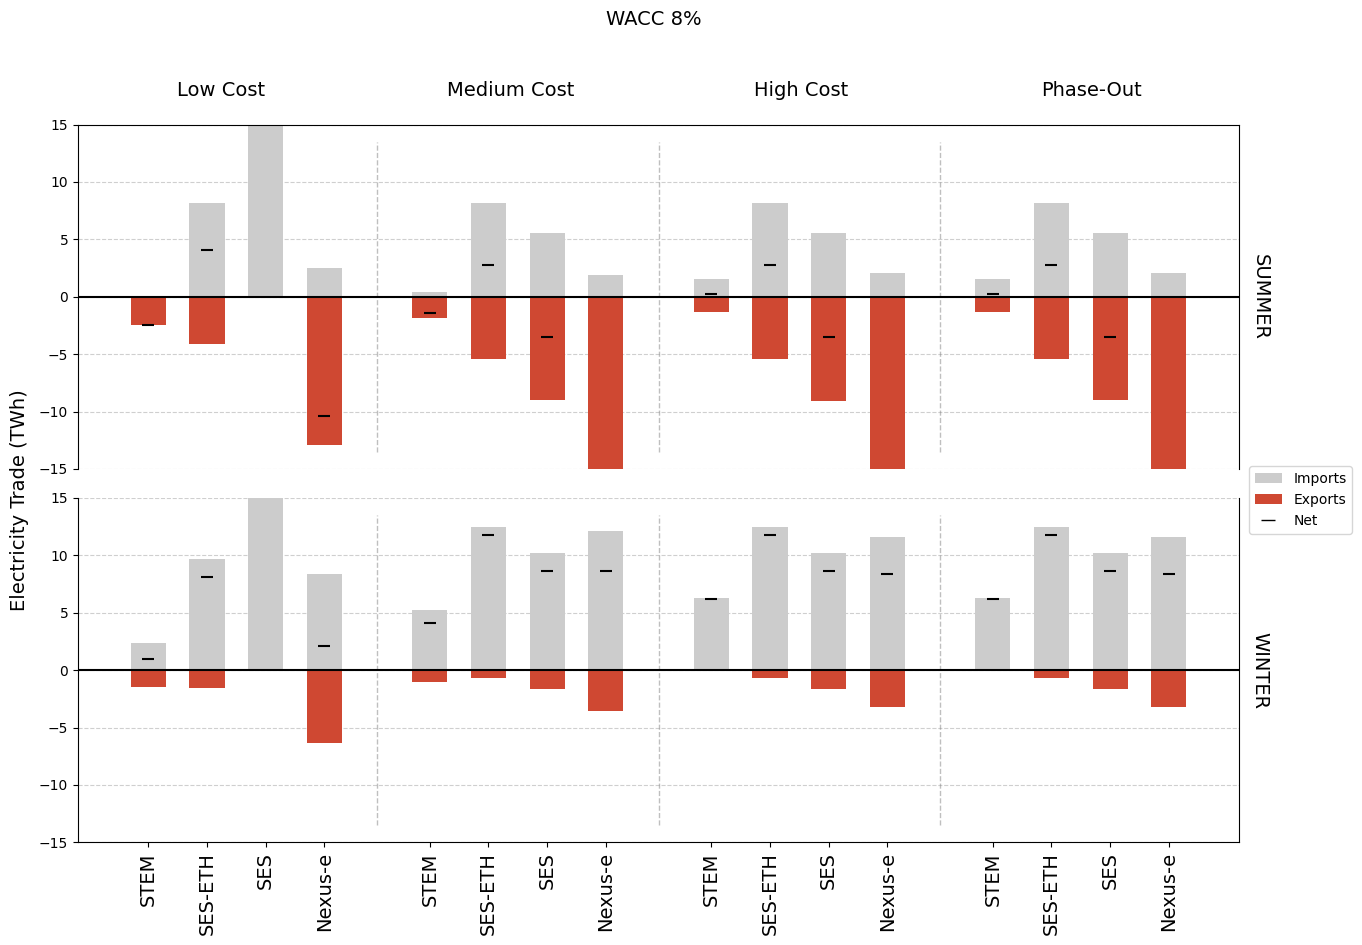

nores


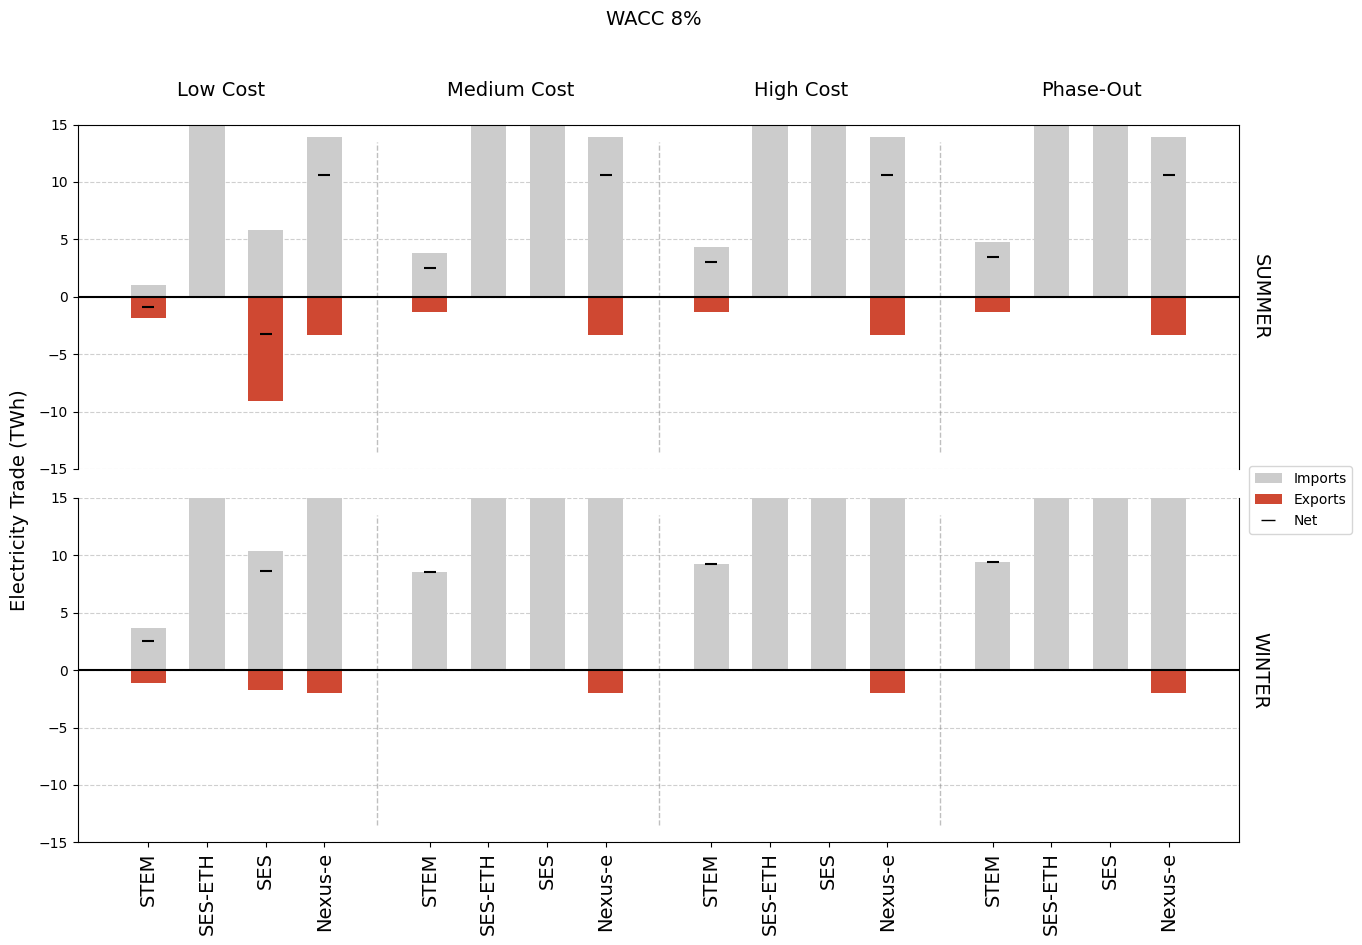

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_seasonal_trade_with_panels(
    data: pd.DataFrame,
    title: str,
    y_lim: int,
    y_step: int,
    output_filename_prefix: str
):
  """Generated with LLM, then tuned manually"""

  variants = [
    "Low Cost",
    "Medium Cost",
    "High Cost",
    "Phase-Out"
  ]
  models = [
    "STEM",
    "SES-ETH",
    "SES",
    "Nexus-e"
  ]
  seasons = ["summer", "winter"]

  index = pd.MultiIndex.from_product(
      [variants, models, seasons],
      names=["Scenario", "Model", "Season"]
  )
  data.set_index(["Scenario", "Model", "Season"], inplace=True)

  # -----------------------------------------------------------------------------
  # 2. Plotting Setup (Seamless Vertical Panels)
  # -----------------------------------------------------------------------------
  # Create 2 rows, 1 column
  # hspace=0 removes the vertical whitespace between subplots
  FONTSIZE = 14
  fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)
  fig.suptitle(title, fontsize=FONTSIZE, y=0.99)

  # Remove vertical space between subplots completely
  plt.subplots_adjust(hspace=0)

  # Colors
  color_import = "#cccccc"
  color_export = "#CF4832"
  color_net = "black"
  edge_color = "black"

  # Configuration
  n_models = len(models)
  n_scenarios = len(variants)
  bar_width = 0.6
  group_gap = 0.8

  # Calculate X positions with gaps
  x_positions = []
  tick_labels_model = []
  current_x = 0
  for scen in variants:
      for mod in models:
          x_positions.append(current_x)
          tick_labels_model.append(mod)
          current_x += 1
      current_x += group_gap
  x_positions = np.array(x_positions)

  # Plot each season
  for i, season in enumerate(seasons):
      ax = axes[i]

      # Data preparation
      df_season = data.xs(season, level="Season")
      df_plot = df_season.reindex(pd.MultiIndex.from_product([variants, models], names=["Scenario", "Model"]))

      y_imports = df_plot["Imports"].values
      y_exports = df_plot["Exports"].values
      y_net = df_plot["Net"].values

      # --- Bars ---
      ax.bar(x_positions, y_exports, color=color_export, width=bar_width, linewidth=0.5)
      ax.bar(x_positions, y_imports, color=color_import, width=bar_width, bottom=0, linewidth=0.5)

      # --- Net Markers ---
      ax.scatter(x_positions, y_net, color=color_net, marker="_", s=80, zorder=10)

      # --- Axis Formatting ---
      ax.set_xticks(x_positions)
      ax.set_xticklabels([]) # Hide default ticks
      ax.set_ylim(ymin=-y_lim, ymax=y_lim)
      y_intervals_major = np.arange(
          -y_step*int(y_lim / y_step),
          1+y_step*int(y_lim / y_step),
          y_step
      )
      ax.set_yticks(y_intervals_major)

      # Grid & Zero Line
      ax.axhline(0, color="black", linewidth=1.5, zorder=5)
      ax.grid(axis='y', linestyle='--', alpha=0.6)
      #ax.grid(which='minor', alpha=0.2)
      #ax.grid(which='major', alpha=0.5)

      # Remove bottom spine of top plot and top spine of bottom plot to merge them visually
      if i == 0: # Top plot (Summer)
          ax.spines['bottom'].set_visible(False)
          ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
          # Add Season Label on the RIGHT
          ax.text(1.01, 0.5, "SUMMER", transform=ax.transAxes,
                  rotation=270, va='center', ha='left', fontsize=FONTSIZE)
      else: # Bottom plot (Winter)
          ax.spines['top'].set_visible(False)
          ax.set_xticks(x_positions)
          ax.set_xticklabels(tick_labels_model, rotation=90, fontsize=FONTSIZE)
          # Add Season Label on the RIGHT
          ax.text(1.01, 0.5, "WINTER", transform=ax.transAxes,
                  rotation=270, va='center', ha='left', fontsize=FONTSIZE)

  # -----------------------------------------------------------------------------
  # 3. Shared Labels (Scenarios at Top, Legend at Bottom)
  # -----------------------------------------------------------------------------

  # Add Scenario Names ONLY ONCE at the very top
  # We use the top axis (axes[0]) coordinates but place them above the figure area
  for j, scen in enumerate(variants):
      start_idx = j * n_models
      end_idx = start_idx + n_models
      group_xs = x_positions[start_idx:end_idx]
      center_x = np.mean(group_xs)
      plot_corner = {
          "x": {
              "left": 0.087,
              "right": 0.916
          },
          "y": {
              "top": 0.9
          }
      }
      # Use the two lines below to check plot corners positions
      #fig.text(plot_corner["x"]["left"], plot_corner["y"]["top"], "I")
      #fig.text(plot_corner["x"]["right"], plot_corner["y"]["top"], "I")
      plot_length = {
          "x": plot_corner["x"]["right"] - plot_corner["x"]["left"]
      }

      # Place text above the top subplot
      fig.text(
          plot_corner["x"]["left"] + (j+1/2) * plot_length["x"] / len(variants),
          plot_corner["y"]["top"],
          scen,
          ha='center',
          va='bottom',
          fontsize=FONTSIZE
      )

  # Add a single Y-label for the whole figure
  fig.text(0.04, 0.5, "Electricity Trade (TWh)", va='center', rotation='vertical', fontsize=FONTSIZE)

  # Separator Lines between Scenarios (drawn across both panels)
  # We draw these on the figure or iterate through axes to ensure they align
  for j in range(1, n_scenarios):
      prev_bar_end = x_positions[(j * n_models) - 1] + bar_width/2
      next_bar_start = x_positions[(j * n_models)] - bar_width/2
      line_pos = (prev_bar_end + next_bar_start) / 2

      # Draw a line that spans both axes vertically
      # We use fig.lines or just draw on both axes with correct limits
      for ax in axes:
          ax.axvline(line_pos, color="gray", linestyle="--", linewidth=1, alpha=0.5, ymin=0.05, ymax=0.95)
          ax.set_axisbelow(True)

  # Unified Legend at the very bottom
  handles, labels = axes[1].get_legend_handles_labels()
  # Manually create handles if labels are empty due to loop logic
  if not handles:
      from matplotlib.patches import Patch
      handles = [
          Patch(facecolor=color_import, label='Imports'),
          Patch(facecolor=color_export, label='Exports'),
          plt.Line2D([0], [0], marker='_', linestyle= "", color='black', markersize=10, label='Net')
      ]
      labels = ['Imports', 'Exports', 'Net']

  fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.92, 0.5))

  # Adjust layout to accommodate top labels and right-side season labels
  plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.93])

  filename = output_filename_prefix
  for variant in variants:
    filename = f"{filename}_{"".join(variant.split(" "))}"
  plt.savefig(
      Path(os.path.dirname(fileResults)) / f"{filename}.png",
      bbox_inches="tight",
      dpi=300
  )

  plt.show()

def get_seasonal_trade(
    wacc: Literal[5, 8],
    scenario: Literal["res", "nores", "resnuc"]
) -> pd.DataFrame:
  # Load data
  seasonal_trade_file = (
    Path()
    / "plots-model-comparison"
    / "results"
    / "nuclear_results_seasonaltrade_20260317.xlsx"
  )
  seasonal_trade = pd.read_excel(seasonal_trade_file)
  # Filter out scenario and WACC variant
  seasonal_trade = seasonal_trade[
      (seasonal_trade.WACC == wacc)
      & (seasonal_trade.Scenario.str.contains("-" + scenario + "-"))
  ]

  # Rename columns
  seasonal_trade.rename(
      columns = {
          "Electricity Imports (TWh)": "Imports",
          "Electricity Exports (TWh)": "Exports",
          "season": "Season"
      },
      inplace=True
  )

  def rename_scenario(scenario: str) -> str:
    if "-low" in scenario:
      output = "Low Cost"
    elif "-medium" in scenario:
      output = "Medium Cost"
    elif "-high" in scenario:
      output = "High Cost"
    elif "-phaseout" in scenario:
      output = "Phase-Out"
    else:
      output = scenario
    return output
  seasonal_trade.Scenario = seasonal_trade.Scenario.apply(rename_scenario)

  seasonal_trade.Exports = -abs(seasonal_trade.Exports)
  for column in ["Imports", "Exports"]:
    seasonal_trade.loc[
        seasonal_trade.Model == "SES",
        column
    ] = seasonal_trade.loc[
        seasonal_trade.Model == "SES",
        column
    ].apply(lambda x: x / 1000)

  seasonal_trade["Net"] = seasonal_trade.Imports + seasonal_trade.Exports
  seasonal_trade.drop(columns=["WACC"], inplace=True)

  return seasonal_trade

for wacc in [5, 8]:
  for scenario in ["res", "resnuc", "nores"]:
    print(scenario)
    seasonal_trade = get_seasonal_trade(wacc, scenario)
    plot_seasonal_trade_with_panels(
        data=seasonal_trade,
        title=f"WACC {wacc}%",
        y_lim=15,
        y_step=5,
        output_filename_prefix=f"seasonal_trade_wacc{wacc}_{scenario}"
    )

## Total Imports

('abroad-resnuc-phaseout', 'wacc_5')


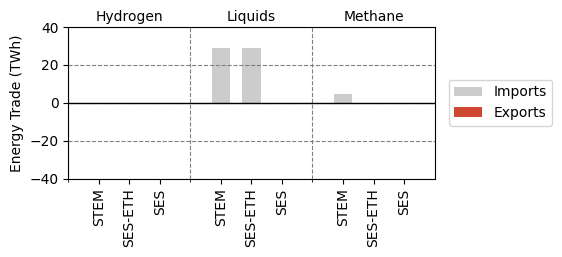

('abroad-resnuc-high', 'wacc_5')


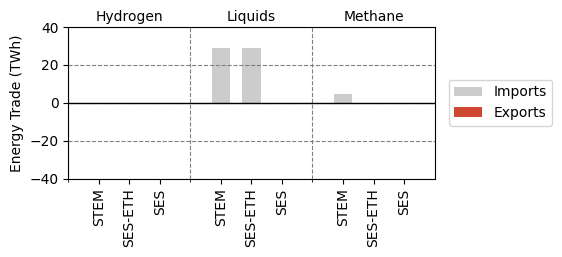

('abroad-resnuc-medium', 'wacc_5')


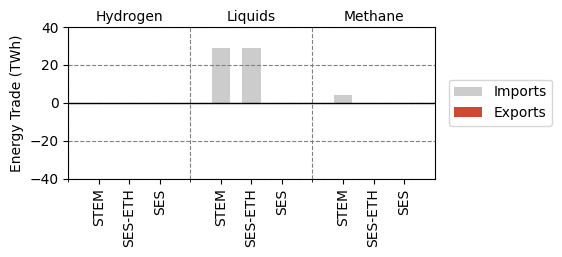

('abroad-resnuc-low', 'wacc_5')


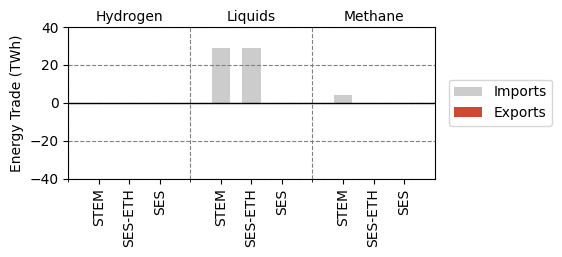

('abroad-res-phaseout', 'wacc_5')


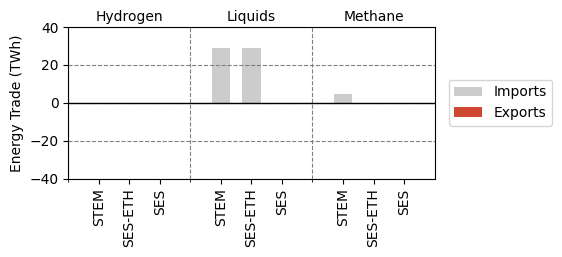

('abroad-res-high', 'wacc_5')


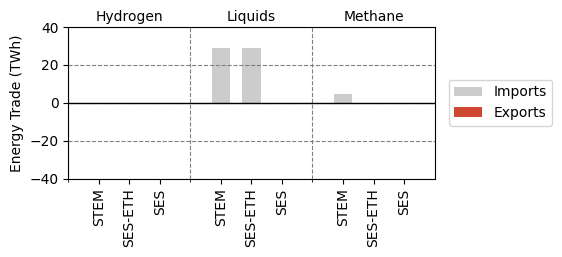

('abroad-res-medium', 'wacc_5')


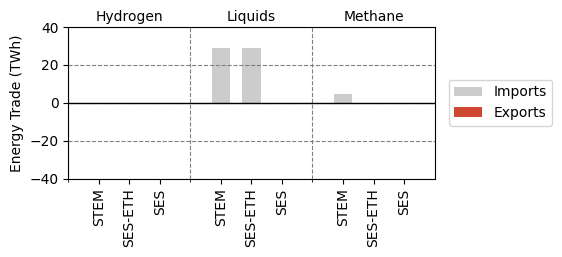

('abroad-res-low', 'wacc_5')


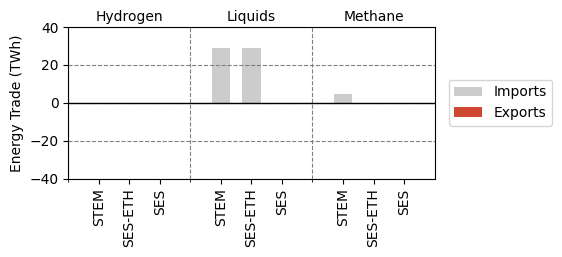

('abroad-nores-phaseout', 'wacc_5')


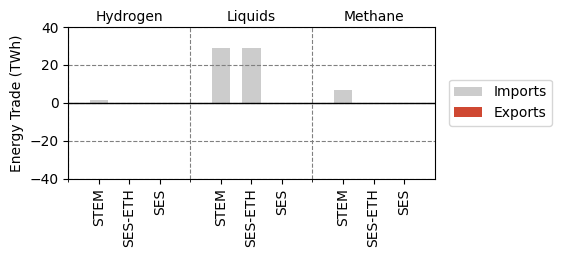

('abroad-nores-high', 'wacc_5')


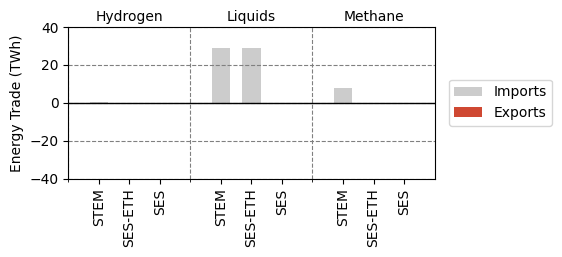

('abroad-nores-medium', 'wacc_5')


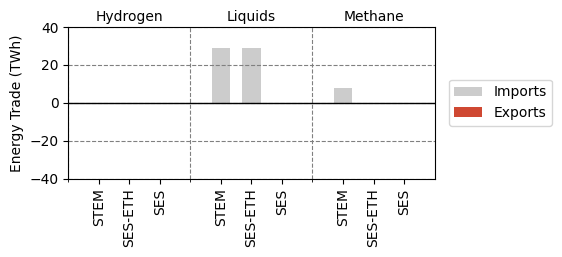

('abroad-nores-low', 'wacc_5')


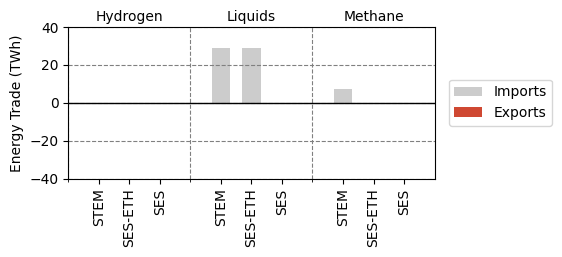

In [ ]:
## Total Imports 5% WACC
fileName = 'total_imports'
year = 2050
signedVarByFuel = {
 #   "Electricity": [
 #      {"name": "Imports", "varName": "electricity_supply",      "techs": ["imports"], "sign": +1, "color": "#CCCCCC"},
 #       {"name": "Exports", "varName": "electricity_consumption", "techs": ["exports"], "sign": -1, "color": "#CF4832"},
 #   ],
    "Hydrogen": [
        {"name": "Imports", "varName": "h2_supply", "techs": ["imports"], "sign": +1, "color": "#CCCCCC"},
        {"name": "Exports", "varName": "h2_fec",    "techs": ["exports"], "sign": -1, "color": "#CF4832"},
    ],
    "Liquids": [
        {"name": "Imports", "varName": "liquids_supply", "techs": ["imports_diesel","imports_biodiesel"], "sign": +1, "color": "#CCCCCC"},
        {"name": "Exports", "varName": "liquids_fec",    "techs": ["exports"], "sign": -1, "color": "#CF4832"},
    ],
    "Methane": [
        {"name": "Imports", "varName": "methane_supply", "techs": ["imports_gas","imports_methane"], "sign": +1, "color": "#CCCCCC"},
        {"name": "Exports", "varName": "methane_fec",    "techs": ["exports"], "sign": -1, "color": "#CF4832"},
    ],
}

scenario_list=[
     ('abroad-resnuc-phaseout','wacc_5'),
    ('abroad-resnuc-high','wacc_5'),
    ('abroad-resnuc-medium','wacc_5'),
    ('abroad-resnuc-low','wacc_5'),
    ('abroad-res-phaseout','wacc_5'),
    ('abroad-res-high','wacc_5'),
    ('abroad-res-medium','wacc_5'),
    ('abroad-res-low','wacc_5'),
    ('abroad-nores-phaseout','wacc_5'),
    ('abroad-nores-high','wacc_5'),
    ('abroad-nores-medium','wacc_5'),
    ('abroad-nores-low','wacc_5')

    ]

listModels = cross_plots.modelsid

for scenario in scenario_list:
    print(scenario)
    cross_plots.plotBarVerticalSignedFuels(
      listModelsid=['ses', 'seseth', 'stem'],
      scenario=scenario,
      signedVarByFuel=signedVarByFuel,
      year=2050,
      scale=1,
      label="Energy Trade (TWh)",
      ylim=(-40, 40),
      fileName=fileName+'_'+scenario[0],
      group_by="fuel",
      multi=False,
      legend=True,
      #pos_legend=“upper right”,
      pos_legend={# This puts the legend outside-right for vertical plots
            "loc": "center left",
            "bbox_to_anchor": (1.02, 0.5),
            },
      width=12,
      height=5,
)



('abroad-resnuc-phaseout', 'wacc_8')


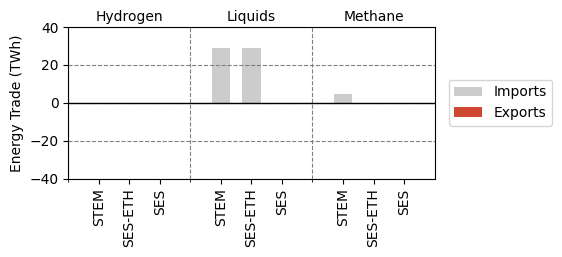

('abroad-resnuc-high', 'wacc_8')


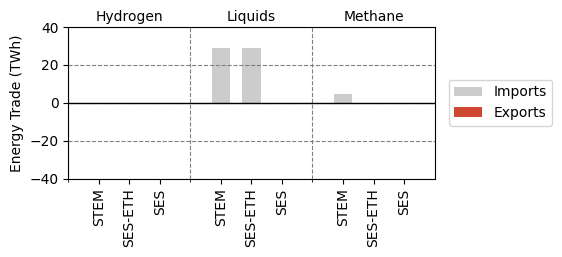

('abroad-resnuc-medium', 'wacc_8')


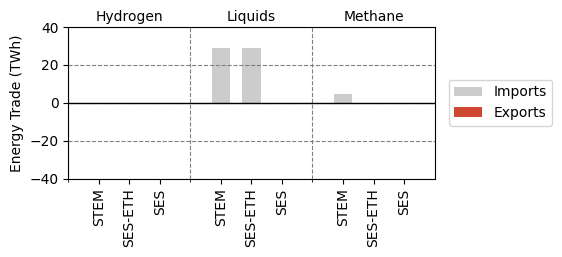

('abroad-resnuc-low', 'wacc_8')


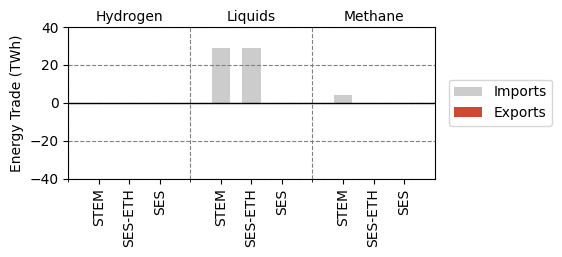

('abroad-res-phaseout', 'wacc_8')


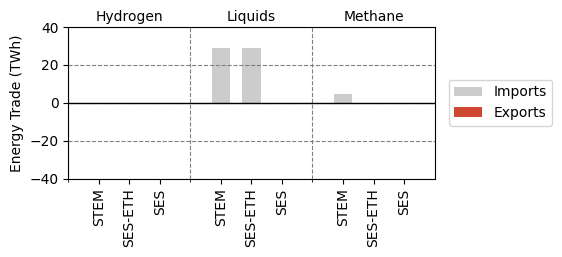

('abroad-res-high', 'wacc_8')


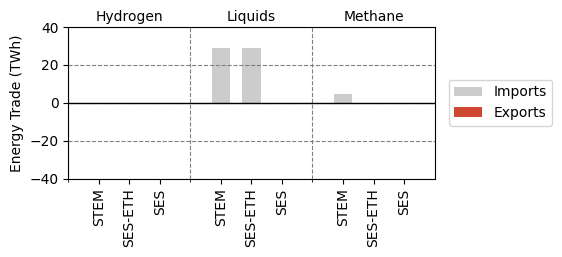

('abroad-res-medium', 'wacc_8')


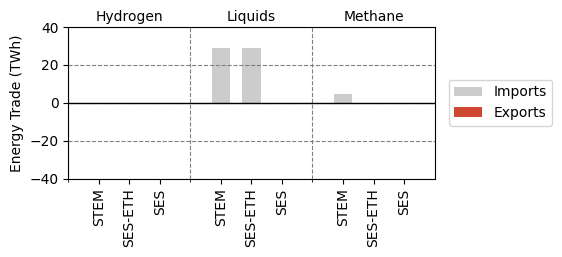

('abroad-res-low', 'wacc_8')


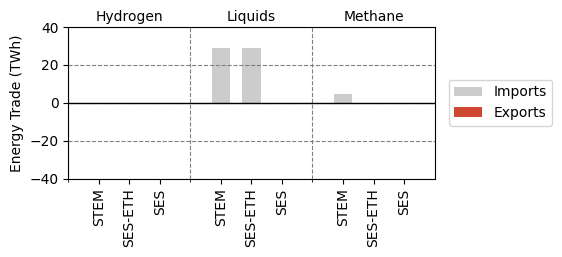

('abroad-nores-phaseout', 'wacc_8')


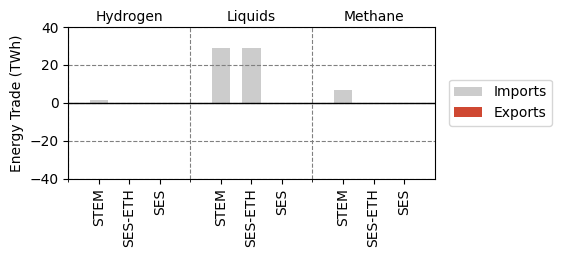

('abroad-nores-high', 'wacc_8')


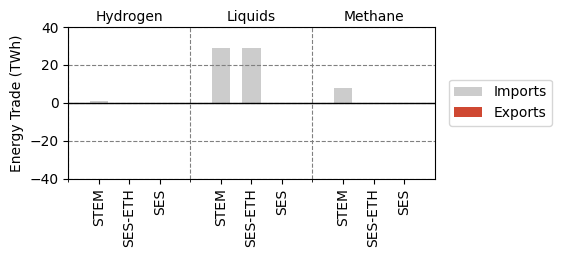

('abroad-nores-medium', 'wacc_8')


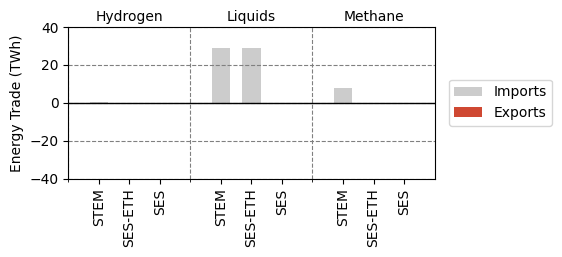

('abroad-nores-low', 'wacc_8')


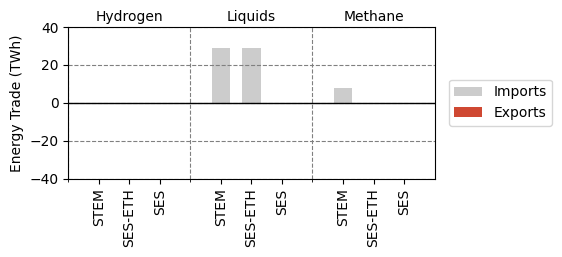

In [ ]:
## Total Imports WACC 8%
fileName = 'total_imports'
year = 2050
signedVarByFuel = {
 #   "Electricity": [
 #      {"name": "Imports", "varName": "electricity_supply",      "techs": ["imports"], "sign": +1, "color": "#CCCCCC"},
 #       {"name": "Exports", "varName": "electricity_consumption", "techs": ["exports"], "sign": -1, "color": "#CF4832"},
 #   ],
    "Hydrogen": [
        {"name": "Imports", "varName": "h2_supply", "techs": ["imports"], "sign": +1, "color": "#CCCCCC"},
        {"name": "Exports", "varName": "h2_fec",    "techs": ["exports"], "sign": -1, "color": "#CF4832"},
    ],
    "Liquids": [
        {"name": "Imports", "varName": "liquids_supply", "techs": ["imports_diesel","imports_biodiesel"], "sign": +1, "color": "#CCCCCC"},
        {"name": "Exports", "varName": "liquids_fec",    "techs": ["exports"], "sign": -1, "color": "#CF4832"},
    ],
    "Methane": [
        {"name": "Imports", "varName": "methane_supply", "techs": ["imports_gas","imports_methane"], "sign": +1, "color": "#CCCCCC"},
        {"name": "Exports", "varName": "methane_fec",    "techs": ["exports"], "sign": -1, "color": "#CF4832"},
    ],
}

scenario_list=[
     ('abroad-resnuc-phaseout','wacc_8'),
    ('abroad-resnuc-high','wacc_8'),
    ('abroad-resnuc-medium','wacc_8'),
    ('abroad-resnuc-low','wacc_8'),
    ('abroad-res-phaseout','wacc_8'),
    ('abroad-res-high','wacc_8'),
    ('abroad-res-medium','wacc_8'),
    ('abroad-res-low','wacc_8'),
    ('abroad-nores-phaseout','wacc_8'),
    ('abroad-nores-high','wacc_8'),
    ('abroad-nores-medium','wacc_8'),
    ('abroad-nores-low','wacc_8')

    ]

listModels = cross_plots.modelsid

for scenario in scenario_list:
    print(scenario)
    cross_plots.plotBarVerticalSignedFuels(
      listModelsid=['ses', 'seseth', 'stem'],
      scenario=scenario,
      signedVarByFuel=signedVarByFuel,
      year=2050,
      scale=1,
      label="Energy Trade (TWh)",
      ylim=(-40, 40),
      fileName=fileName+'_'+scenario[0]+'_wacc8',
      group_by="fuel",
      multi=False,
      legend=True,
      #pos_legend=“upper right”,
      pos_legend={# This puts the legend outside-right for vertical plots
            "loc": "center left",
            "bbox_to_anchor": (1.02, 0.5),
            },
      width=12,
      height=5,
)
